In [4]:
import re, random
import numpy as np
import pandas as pd
import starfile, mrcfile
import os, sys, glob
import math as m
from matplotlib.pyplot import subplots, savefig
from skimage.measure import regionprops, marching_cubes
#from skimage.filters import threshold_otsu
from scipy.ndimage import gaussian_filter, center_of_mass
from scipy.spatial import cKDTree
#from scipy.spatial.transform import Rotation as R #dont need this anymore
import seaborn as sns
from tqdm import tqdm
from time import sleep




### COORDINATES ARE IN (Z, Y, X)

# Functions

## Get micrograph and object name

In [13]:
def get_micrograph_name(segmentation_file_path):
    '''
    This function, from the name of the segmentation file, will be able to get the .tomostar microgaph file.
    It will also obtain which object the membrane is, and allow the star file to be written out per object

    :param segmentation: string of the file path
    :type segmentation: str
    :return: Name of the .tomostar file
    :rtype: str
    '''
    path_parts = segmentation_file_path.split('/')
    segment_file = path_parts[-1]
    mgraph_name_parts = segment_file.split('_')
    mgraph_name = mgraph_name_parts[0] + '_' + mgraph_name_parts[1] + mgraph_suffix

    #getting object name

    return mgraph_name



## Safe Marching cubes

## Create a function that will perform marching cubes iteratively. Specifically:
- if it encounters an error with the contour level, automatically increase or decrease the contour level
    increase logarithmically or scaled?
- only have 3 attempts

In [4]:
def safe_marching_cubes(map, initial_level, step_size):
    '''
    This function creates a mesh from a segmentation as a Numpy array. 

    :param map: Numpy ndarray of the membrane segmentation
    :param initial_level: The initial contour level to use on the segmentation
    :param step_size: If initial contour does not work, then step size determines how far to search
    :rtype map: Numpy ndarray
    :rtype initial_level: (float, int)
    :rtype step_size: (float, int)

    :return: return the coordinates of the triangular mesh vertices, their normals relative to the density at that position, faces and values

    '''

    #ensure that initial level and step size are either floats or integers
    if not isinstance(initial_level, (float, int)):
        raise TypeError('Initial contour level must be float or integer')

    if not isinstance(step_size, (int, float)) or step_size > 1 or step_size<0:
        raise TypeError('Step size must be an integer or float and be between 0 and 1')
    
    
    max_attempts = 10

    #getting the max and min contour levels
    cmax = np.max(map.copy())
    cmin = np.min(map.copy())


    for attempt in range(max_attempts):
        if initial_level < cmin:
            initial_level += 2* (cmin - initial_level) #multiple 2 to get one up the other way
        elif initial_level > cmax:
            initial_level -= 2*(initial_level - cmax)
        else:

            try:
                verts, faces, normals, values = marching_cubes(map.copy(),level=initial_level)
                return verts, faces, normals, values
            except RuntimeError:
                print(f"\nmarching_cubes failed at level={initial_level}, trying different contour...")

                # adjust level downward
                initial_level += (m.e**(0.25*initial_level)-0.7)
        
    raise RuntimeError("Marching cubes failed after multiple attempts")

## Membrane sampling

## Sampling our mesh to get our particle coordinates
- Pairwise, calculate the distance between every pair of vertices, calculate the euclidean distance between them
- If they fall within the sampling rate - append to a list...for now

There are two algorithms which can be used:

- poisson disk sampling
or 
- cKDTREE algorithm

### Using KD-tree to sample points on the membrane
Logic:
- create a spatial tree using cKDtree algorithm
- check each point in the tree and create a circle sampling radius, set to the 'grid sampling' variable
- When we accept a point, we create a sphere of the grid sampling radius.
- Any points inside this radius is 'too close' 
- These points are marked as used and are blocked. 

This enforces the grid sampling restraint

Below is essentially a greedy maximal independent set problem.
Below needs further debugging - something is slightly wrong with the algorithm

We need a way of reducing bias in the membrane sampling. As we are doing greedy sampling where a point within a dense area can be picked and the points around it are discarded, this could bias the sampling potentially.
Either:
- density aware (points with likely least neighbours are taken first)
- maintaining particle list set and just randomising the indices

In [ ]:
def shuffle_membrane_sampling(coords, normal_vectors):
    '''
    This function takes a set of points which have been curated by making a mesh around volumetric data, in mrc format.

    :param coords: A numpy array of coordinates which will act as particle coordinates
    :param normal_vectors: A numpy array of the vectors of the normal from a marching cubes output 
    :type coords: Numpy n-dimentional array
    :type normal_vectors: Numpy n-dimensional array

    :return:
    :rtype: dictionary of particle coordinates and their normal vectors

    '''
    particles={}
    used=set()
    global grid_sampling
    #have a seed for reproducible permutations
    #shuffle the numpy array to reduce the bias in the construction of the search tree
    np.random.seed(1);  coords_shuffle = np.random.permutation(coords)
    tree = cKDTree(coords_shuffle)

    for i, particle in enumerate(coords_shuffle):
        #print(f'Processing particle {i} of {len(coords)}')
        if i in used:
            continue
        
        particles[i]={'coordinates': particle,
                      'normal':normal_vectors[i]}

        #find all neighbours within a given sampling distance
        neighbours = tree.query_ball_point(x=particle, r=grid_sampling)
        used.update(neighbours)

    return particles



In [ ]:
b = np.array([[0.8, 0.9, 1], [0.2, 0.1, 0.98], [0.33, 0.11, 0.54]])
a = np.array([[10, 34, 200], [98, 23, 100], [56, 23, 300]])

c = np.concatenate((a, b), axis=1)
c = rng_test.permutation(c)
c

array([[5.6e+01, 2.3e+01, 3.0e+02, 3.3e-01, 1.1e-01, 5.4e-01],
       [9.8e+01, 2.3e+01, 1.0e+02, 2.0e-01, 1.0e-01, 9.8e-01],
       [1.0e+01, 3.4e+01, 2.0e+02, 8.0e-01, 9.0e-01, 1.0e+00]])

In [ ]:
c[0][3:]

array([0.33, 0.11, 0.54])

In [14]:
def non_random_membrane_sampling(coords, normal_vectors): #want verts (coords) and norms
    '''
    This function takes a set of points which have been curated by making a mesh around volumetric data, in mrc format.

    :param coords: A numpy array of coordinates which will act as particle coordinates
    :param normal_vectors: A numpy array of the vectors of the normal from a marching cubes output 
    :type coords: Numpy n-dimentional array
    :type normal_vectors: Numpy n-dimensional array

    :return:
    :rtype: dictionary of particle coordinates and their normal vectors

    '''

    used=set()
    tree = cKDTree(coords)
    particles = {}
    global grid_sampling

    for i, particle in enumerate(coords):
        #print(f'Processing particle {i} of {len(coords)}')
        if i in used:
            continue
        #here we make a new particle dictionary with the index of verts and norms
        particles[i]={'coordinates': particle,
                      'normal':normal_vectors[i]}

        #find all neighbours within a given sampling distance
        neighbours = tree.query_ball_point(x=particle, r=grid_sampling)
        used.update(neighbours)

    return particles


In [ ]:
def density_based_sampling(coords, normal_vectors):
    '''
    This function samples a membrane but is density based. 
    As the cKDTree binary search is a greedy algorithm, samples which are more closer together wipe out more points, in which those points could have sparse neighbourhoods.
    
    We essentially want to remove as much bias as we can.

    :param coords: A numpy array of coordinates which will act as particle coordinates
    :param normal_vectors: A numpy array of the vectors of the normal from a marching cubes output 
    :type coords: Numpy n-dimentional array
    :type normal_vectors: Numpy n-dimensional array

    :return:
    :rtype: dictionary of particle coordinates and their normal vectors

    '''
    global grid_sampling
    used=set()
    particles={}
    #make the KDtree
    #ensure reproducible randomness with seed otherwise indexing will not work
    np.random.seed(1); coords_shuffle = np.random.permutation(coords)
    tree = cKDTree(coords_shuffle)
    #create a list of how many neigbours are encountered by each point
    neighbourhood_density = [len(tree.query_ball_point(x=particle, r=grid_sampling)) for particle in coords_shuffle]
    #sort this list and get the indices in which we conduct this search
    order = np.argsort(neighbourhood_density)

    #now iterate through this order
    for i in order:
        if i in used:
            continue
        particles[i] = {'coordinates':coords[i],
                        'normal':normal_vectors[i]}

        neighbours = tree.query_ball_point(x=coords_shuffle[i], r=grid_sampling)
        used.update(neighbours)
    
    return particles







# Adapting the Script

## Several tweaks to the code need to be made.
1. Scaleability - feeding the data into the script
2. Euler angles
3. Only pick on the outside of the membrane - we are currently picking on the outside and inside leaflet

In [ ]:
os.getcwd()

'/Users/jantinoro/Documents/LIDo/Rotation_2/coding/tomography_project/scripts/Notebooks'

## Feeding in the data

Overall what we want to do is:
- Extract the object densities but keeping the full box size of the tomogram, otherwise particle coordinates will be way off
    - Automate the extraction of the objects within the full tomograms
        - Read in the full segmentation
        - Assign pixel values to objects - the segmentation has done that for us
        - Once picked and extracted (zero everything outside), normalise pixel values to 0-1
        - incorporate user input, based on a specified pixel value or range, users can choose what objects to extract
    - Perform manual object annotation and extraction as desired in chimerax (same as before but make sure to keep the whole) using volume mask command
        - full map = True (this keeps the box size as the entire tomogram)
    - As before, but just assign an initial contour level at the lowest level (0.5) -> This would work, but would not be scalable
- apply a volume based filter to remove any false positives in the segmentation
    - There are specs of density which clearly aren't real, so would have a 



## Euler Angles
The z-axis should be pointing out of the membrane, but in chimerax, they are not.

This could be due to several reasons:
- ChimeraX not reading the star file correctly
    - star2dynamo, read motl list into artiax - then we can see if chimerax is reading it wrong
    - import into Relion and average - this should tell us if angles are wrong 
- Angles are in wrong convention
- Angles miscalculated, misinterpreting the angle
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

- Rot - set to random
- Put object name into star file as well so we can keep track of the object



## Data feeding

### Extract out the objects

In [ ]:
#reading in the full segmentation data
ts_1166 = '/Users/jantinoro/Documents/LIDo/Rotation_2/coding/data/segmentation/TS_1166_10.00Apx_MemBrain_seg_v10_beta.ckpt_segmented.mrc'

full_seg_data = (mrcfile.open(ts_1166)).data
ts_1166 = full_seg_data.copy()
#this will be a triple nested dictionary
#
full_data_dict = {}


## Object Extraction function

In [15]:
def object_extraction(mrc_array):
    """
    Extract objects from a labeled 3D segmentation mrc file.

    :param mrc_array: 3D labeled segmentation array where each integer corresponds to an object.
    :type mrc_array: numpy.ndarray

    :return: 
        - objects_dict: Dictionary mapping object IDs to their region properties.
        - volume_array: Sorted array of object volumes (voxel counts) of each object.
    :rtype: tuple(dict[str, RegionProperties], numpy.ndarray)
    """

    if not isinstance(mrc_array, (np.ndarray)):
        raise TypeError('Data must be a numpy ndarray')
    
    ###MAKING THE CODE MUCH MORE EFFICIENT
    #using skimage measure.regionprops
    #.area atribute = voxels
    #.coords gives positions of all voxels

    #using regionprops to get all the labelled data
    #this compresses the data and stores it so we can apply attributes to obtain the desired data
    objects_dict={}
    volume_list = []
    objects=regionprops(mrc_array) # we get a list
    #getting data into the dictionary and also calculating the array to get our volume array
    for object in range(len(objects)):
        objects_dict[f'Object{object+1}'] = objects[object] #as they are in indexing order
    
    #obtaining the volumes and creating a volume array sorted in ascending order
    for label, data in objects_dict.items():
        volume = np.int64(data.area) #we convert to integer - reduce memory strain
        volume_list.append(volume)
    volume_array = np.sort(volume_list)
    #if we do otsu thresholding, volume_array likely stays unsorted


    return objects_dict, volume_array





In [ ]:
dict_1166, volumes_1166 = object_extraction(ts_1166)



## Preliminary code to retrieve the objects in a tomogram - building the function

In [ ]:
#All of the below occurs on a PER FILE basis, so we should get filey_objectx


#object dictionary, nested
#object1: array and volume
objects_dict = {}

#getting the occurances of each voxel value
#voxel value of 2 = object 2
voxel_counts = np.bincount(full_seg_data_copy.ravel()) #collapse the 3d array into 1 dimension - dimensions do not matter for volume, as we have discrete voxel data
voxel_vol = pixel_size ** 3 #in Angstroms cubed
amount_of_objects = len(voxel_counts)
voxel_counts
#index = value in the array
#value at the index = amount of occurances of that index
#i.e., pixel value of 0 has 158488624 occurences


array([158488624,    355848,        44,     11747,   1005582,         2,
              47,      1049,       843,       768,      1814,     11217,
            6287,        11,        22,     42651,      9942,       844,
            1894,    356710,      1942,        17,      4260,      1222,
               5,        41,     61319,     44647,     11539,      1624,
             244,         9,        96,         1])

In [ ]:
#extract objects, calculate volumes, and filter
#should have a cleaned set of objects at the end
for i in range(amount_of_objects):
    #skip over where the array is 0 - this is nothing
    if i == 0:
        continue
    #masking out the objects
    object_seg = (full_seg_data_copy==i)*1 #change all the values to 1 once they have been selected
    #volume/voxel count based filter
    #any noise should have a small volume

    #create a nested dictionary as each object will have its array, and its associated volume
    objects_dict[f'Object{i}'] = {'Data':object_seg,
                                  'Voxels': voxel_counts[i]} #volume in Angstroms^3

In [ ]:
##This can be a function
#volume getter sorter

#getting just the volume data within a tomogram segmentation
## look at the univariate distribution of the volumes
vol_list = []
for i in objects_dict.values():
    vol_list.append(i['Voxels'])
vol_array = np.array(vol_list)

#make an array - easier to plot and handle the data
#index+1 = object number
#e.g. index 0 = object 1
vol_array
volume_sorted = np.sort(vol_array) #in ascending order
volume_sorted

array([      1,       2,       5,       9,      11,      17,      22,
            41,      44,      47,      96,     244,     768,     843,
           844,    1049,    1222,    1624,    1814,    1894,    1942,
          4260,    6287,    9942,   11217,   11539,   11747,   42651,
         44647,   61319,  355848,  356710, 1005582])

In [ ]:
np.sort(voxel_counts[1:])

array([      1,       2,       5,       9,      11,      17,      22,
            41,      44,      47,      96,     244,     768,     843,
           844,    1049,    1222,    1624,    1814,    1894,    1942,
          4260,    6287,    9942,   11217,   11539,   11747,   42651,
         44647,   61319,  355848,  356710, 1005582])

## Make volume threshold to filter volumes 
- want to try seperate noise from signal 

### There are three algorithms which we can use
#### Automated approaches
Otsu algorithm:
- good for bimodal data, which I could assume is the case as random noisy membranes would bunch up together (mode closest to 0), compared o actual membranes
- Perform it on the log data, as the unlogged data is so vastly different that it does not have any distribution really


#### Semi-automated
Percentile-based cutoff
- simple, less computation, robust and simple but less adaptable
- 90th and 95th percentiles would probably be good enough

"Knee-detection"
- plot normalised curve of the volumes
- noise should be around 0, and the signal should cause the curve to significantly rise
- the point at which the sharp increase occurs is the cutoff


----
To improve the threshold, we could create a (triple) nested dictionary to store all the data across the tomograms
- {ts_1234:
    {object1:{
            Volume:
    }}}

- We can then do the thresholding 

#### Knee detection

In [18]:
def plot_knee(normalised_volume, index_threshold, norm_threshold, micrograph):
    """
    This function plots the volume-based filter so users can visualise the filter being imposed.

    :param normalised_volume: array of volumes which have been normalised against the max volume within the array, and be assorted in ascending order
    :param index_threshold: Integer value giving the index in which the objects should be retreieved
    :param norm_threshold: threshold value of the max normalised value 
    :type normalised_volume: numpy.ndarray
    :type threshold: int, np.int64

    :return:
        - fig: graphical figure
        - ax: plotted axis
    :rtype: tuple(fig, ax)
    """
    if isinstance(index_threshold, (str, float)):
        raise TypeError('Threshold must be an integer')
    if np.max(normalised_volume) > 1 or np.min(normalised_volume) <0:
        raise ValueError('Volume array must be normalised!')

    fig, ax = subplots(figsize=(5,5))
    #getting the x-axis ticks, which are the indices of the data
    index = np.arange(len(normalised_volume))

    sns.scatterplot(y=normalised_volume, x=index)
    #adding the diagonal
    ax.axline(xy1=(0,0), xy2=(len(normalised_volume), 1), linestyle='-', color='red')
    #adding line for data
    ax.plot(index, normalised_volume, color="#008080", alpha=0.8)
    #adding the vertical threshold line
    #ax.axvline(index_threshold, color='red', linestyle=(5, (10,3)), alpha=0.35, label='Threshold')
    ax.axhline(norm_threshold, color='red', linestyle=(5, (10,3)), alpha=0.35)
    #adding labels
    ax.set_title(f'Max-volume normalised volumes of {micrograph}')
    ax.set_ylabel('NSR value w.r.t to the largest volume object') #NSR = N:Signal ratio intuition is, if the signal is much larger than noise, NSR = 0. Max-normalised volumes are essentially calculating this ratio
    ax.set_xlabel('Index of the data')
    #adding labels for thresholds
    ax.text(0, norm_threshold, f'{round(norm_threshold, 3)}',
    color='red',
    va='center', ha='right',
    transform=ax.get_yaxis_transform())

    #ax.text(index_threshold, 0, f'{index_threshold}',
    #color='red',
    #va='top', ha='center',
    #transform=ax.get_xaxis_transform())

    return fig, ax

In [17]:
def knee_detection(volume_array, objects_dictionary, micrograph, index=None): #may need full dict (which also contains tomogram)
    '''
    This function performs a volume based filtering of the objects in the segmentation. 


    :param objects_dictionary: Dictionary containing each object and associated data. This should be the dictionary of of a single tomogram and not a full dictionary.
    :param volume_array: array of the counts of each voxel value, sorted in ascending order.
    :param index: index of which iteration we are in when looping through the object data within a tomogram.
    :type objects_dictionary: dict
    :type volume_array: numpy.1darray

    :return objects_filtered: Dictionary of filtered objects
    :rtype objects_filtered: dict

    '''
    #error handling
    #if not isinstance(objects_dictionary, (dict)):
        #raise TypeError('Dictionary containing objects and their regional properties must be supplied!')
    if not isinstance(volume_array, (np.ndarray)):
        raise TypeError('Volume array must contain the counts of each object/pixel value')


    try:    
        #normalise the volume array against the largest volume
        #in case users do not have array sorted by size 
        volume_array = np.sort(volume_array)
        max_volume = np.max(volume_array)
        max_normalised = []

        for volume in volume_array:
            vol_norm = volume/max_volume
            max_normalised.append(vol_norm)
        #obtain the indexes - this is useful for plotting, as we will plot the indexes of the data against their normalised value
        

        #performing the volume based filtering
        #calculating the perpendicular distance from each point to a diagonal
        #seems a little funky, but the diagonal has a y=mx form
        #form of ax + by + c = 0
        #y=-(a/b)x - c

        slope = (1-0)/(len(max_normalised)-0)
        a = slope * -1
        b=1
        #finding the perpendicular distance to line across all indices of the array
        #x = indices
        #y = max-normalised volume
        dist_list = []
        for x in range(len(volume_array)):
            y=max_normalised[x]
            distance = (np.abs((a*x)+(b*y)))/np.sqrt((a**2)+(b**2))
            dist_list.append(distance)
        dist_array=np.array(dist_list)

        #useful for plotting and visualising the readout
        threshold = np.argmax(dist_array) #this gives the index/position at which the filter occurs
        threshold_normalised_value = max_normalised[threshold]

        #plotting of the filter so it can be visualised


        
        #pulling out the objects which have passed the filter
        #this uses the index filter, not the noise : signal ratio
        #if you use the ratio, essentially make a boolean mask of which value satisfy the boolean: volume_array or dict.items() (use for loop for dict) >threshold_normalised_value
        objects_dictionary_copy = objects_dictionary.copy()
        objects_sorted_list = sorted(objects_dictionary.items(), key=lambda x: x[1].area, reverse=False) #sort the dictionary by area size
        objects_filtered = dict(objects_sorted_list[threshold:])


        ##Visualising the filter
        #global index
        if index is not None:
            if index % 3 == 0: #this is so we do not plot all the tomograms - but this can be deleted
                plot_knee(max_normalised, index_threshold=threshold, micrograph=micrograph, norm_threshold=threshold_normalised_value)
        else:
            plot_knee(max_normalised, index_threshold=threshold, micrograph=micrograph, norm_threshold=threshold_normalised_value)


        return objects_filtered
    except Exception as e:
        print('There was an error')
        print(f'Error: {e}')
        raise(e)
    



#### Knee plotting testing - checking visuals

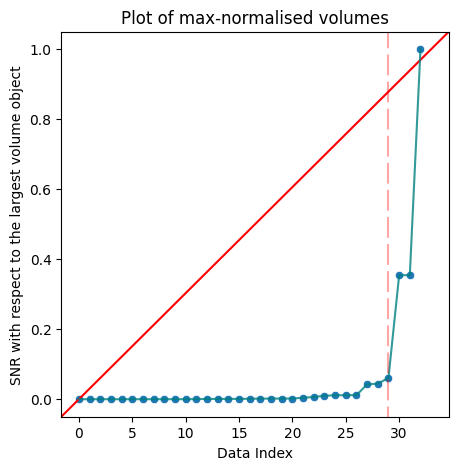

In [ ]:
#plotting everything
fig, ax = subplots(figsize=(5,5))
sns.scatterplot(y=max_norm_sort, x=index_x)
ax.set_title('Plot of max-normalised volumes')

ax.axline(xy1=(0,0), xy2=(len(max_norm_sort), 1), linestyle='-', color='red')
ax.plot(index_x, max_norm_sort, color='#008080', alpha=0.8)
ax.set_ylabel('SNR with respect to the largest volume object')
ax.set_xlabel('Data Index')
ax.axvline(threshold, color='red', linestyle=(5, (10,3)), alpha = 0.35, label='Threshold')

### We may have to write MRCs of each object ??
- write mrc file
- update data and header
- set voxel size

### Otsu thresholding

In [ ]:
def otsu_threshold_plot(volume_array):
    

In [ ]:
vol_array

array([ 0.        ,  0.        ,  0.69314718,  0.69314718,  1.09861229,
        1.94591015,  2.19722458,  2.30258509,  2.39789527,  2.63905733,
        2.77258872,  2.83321334,  2.89037176,  3.58351894,  4.31748811,
        4.56434819,  4.74493213,  4.76217393,  4.77068462,  5.02388052,
        5.70711026,  5.768321  ,  5.89440283,  5.91350301,  6.76734313,
        7.04490512,  7.34213173,  7.57404501,  7.57916797,  7.63482068,
        7.70706266,  7.85515701,  7.87777633,  8.10258643,  8.14438887,
        8.61377529,  8.85237889,  9.043459  ,  9.24493502,  9.3326465 ,
        9.43188264,  9.60136843,  9.61673838,  9.97450504, 10.18028561,
       10.38083912, 10.42735773, 10.49731151, 11.03616305, 11.2524564 ,
       11.58347712, 12.31002717, 12.37797343, 12.91534413, 13.08763942,
       13.95644486])

In [ ]:
log_vol = np.log(vol_array)

In [ ]:
#taking the logs to just bunch up our data
log_vol = np.log10(vol_array[:])
log_vol

#implement a filter via thresholding and plot that on the histogram

thresh = filters.threshold_otsu(log_vol, nbins=10)
thresh

#checking the indices in which volumes are greater than thresh

np.count_nonzero(log_vol > thresh) #counts all the true values
#32 objects are retained with this filter

np.int64(32)

In [ ]:
thresh

np.int64(237512)

#### Plotting function to visualise the otsu thresholding

In [ ]:
def otsu_hist(vol_data, threshold):
    fig, ax = subplots(figsize=(8,8))
    #fancy formatting
    custom={"grid.color": "black"}
    sns.histplot(data=vol_data, bins=15, alpha=0.5, kde=True, color='purple',
                 stat='count', linewidth=1, edgecolor='black');
    sns.set_theme(style='dark', rc=custom);
    sns.set_context('paper')
    #label axis
    ax.set_xlabel('Volume in log10(Angstroms^3)')
    ax.set_title('Distribution of log base10 transformed segmentation volumes')
    ax.axvline(threshold, color='r', linestyle='--',
               alpha=0.75)
    return fig, ax

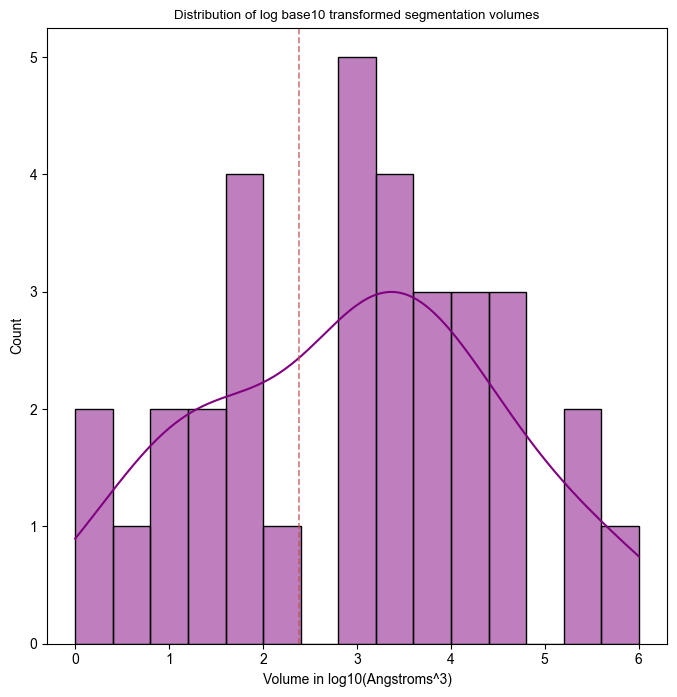

In [ ]:
otsu_hist_hist(log_vol, thresh);

## Function for user choice from filtered objects

In [19]:
def object_choice(data, ask_user=None):
    '''
    This function takes a user's choice of tomogram's segmentation files, and can specify the specific objects witin these tomograms in which they wish to keep.
    The user can only choose from objects which have passed the volume-based filter which aims to filter out noise.

    The output of this function can be used to extract particle coordinates and output a star file.

    :param data: Dictionary containing the data. Key: tomogram, value: tomogram object data (also dictionary)
    :type data: dict

    :return data_final: original dictionary modified with the appropriate choices from the user
    :rtype data_final: dict
    '''

    if ask_user == True:
        #retroactive selection of objects from the filtered objects pool
        object_id_choice_list=[]
        #getting the users choices
        #use regex operator to just get the numbers
        tomo_choice_list = re.findall(r'\d+', input(f'Tomograms to select from:\n\n\n{list(data.keys())}Tomogram IDs you wish to select from:')) #just need the tomogram number, TS_1234 -> just need 1234
        tomo_list = [f'{x}.tomostar' for x in tomo_choice_list]
        data_choice_filtered={}
        for i in range(len(tomo_list)):
            object_choice = input(f'What object IDs would you like to select from tomogram {tomo_list[i]}?')
            tomo_object_id_choice = re.findall(r'\d+', object_choice)
            object_id_choice_list.append(tomo_object_id_choice)
            
            
        choice_dictionary = dict(zip(tomo_list, object_id_choice_list))
        #picking out the data

        #first go through choices, then retrieve data for tomogram 
        #take the data we want and change original dict
        for tomo_choice, choices in choice_dictionary.items():
            new_data={}
            print(tomo_choice)
            #filter out
            tomo_data = data.get(f'TS_{tomo_choice}')
            for object, object_data in tomo_data.items():
                if str(object_data.label) in choices:
                    new_data[object] = object_data
            data[f'TS_{tomo_choice}'] = new_data
            data_choice_filtered[f'TS_{tomo_choice}'] = new_data
        return data_choice_filtered
    elif ask_user == False:
        return data


## Function for users to pick certain files from a list of files

In [20]:
#given a list of files, does the user want to pick any specific files

def file_choice(files_list):
    '''
    Take a list of files obtained from a directory, and if a user has select tomograms for which they wish to process, they can select them.

    :param files_list: list of absolute file paths.
    :rtype files_list: list

    :return file_choices: list of absolute paths of the files which the user wishes to process.
    :rtype file_choices: list

    '''
    global files
    user_decision = input(f'Are there specific tomograms from you wish to process?')

    if user_decision.lower() in ['y', 'yes']:
        print(f'Tomograms available to select from:\n\n{[file.split("/")[-1] for file in files]}\n')
        tomo_choice = re.findall(r'\d+', input('What specific tomograms you would like to process?'))
        files_choice = []
        for tomo_id in tomo_choice:
            for file in files_list:
                if tomo_id in file:
                    files_choice.append(file)
            
        return files_choice
    if user_decision.lower() in ['n', 'no']:
        return files_list



In [ ]:
a = '1234'
b = '9812346'
a in b

True

## Extract and store function

In [21]:
def extract_and_store(files):
    '''
    Takes a list of tomogram segmentations, identifies all the objects, filter objects by NSR and provides a filtered object dataset, per tomogram.
    The user also has the option to, from the objects filtered set, choose objects of interest.

    :param files: list of segmentation files with .mrc suffix
    :type files: list

    :return full_data_dict: dictionary keyed initially by tomogram/segmentation, and then attached to object data contained within that.
    :rtype: dict

    '''
    #get all objects and make a dictionary with all the data in them
    full_data = {}

    ask_user = input('Before processing, are there any objects of interest you would like to select from the filtered set during processing?')
    while ask_user.lower() not in ['y', 'yes', 'n', 'no']:
        print('Answer must be yes or no!')
        ask_user = input('Before processing, are there any objects of interest you would like to select from the filtered set during processing?')
    if ask_user.lower() in ['y', 'yes']:
        ask_user = True
    elif ask_user.lower() in ['n', 'no']:
        ask_user = False

    ## BEGIN PROCESSING NOW
    total_files = len(files)
    with tqdm(total=total_files, desc='Running Extraction', unit='file', leave=True) as pbar:
        for file in files:
            try:

                mgraph = get_micrograph_name(file)
                with mrcfile.open(file, mode='r') as mrc:
                    segmentation = mrc.data.copy()
                shape_zyx = segmentation.shape
                
                pbar.set_postfix_str(f"Processing {mgraph}... | shape (zyx)={shape_zyx}")
                # getting objects and filtering out noise
                objects_dict, volumes = object_extraction(segmentation)
                objects_filtered = knee_detection(objects_dictionary=objects_dict, volume_array=volumes, micrograph=mgraph) #can get rid of index if you want to plot everything
                #objects filtered
                full_data[f'{mgraph}'] = objects_filtered
            
            except Exception as e:
                print(f'\nThere was an error with file:{file}')
                print(f'Error:{e}')
                raise(e)
            pbar.update(1)
        full_data = object_choice(data=full_data, ask_user=ask_user)
    # --- let's print out the data we have extracted ---
    for tomo, data in full_data.items():
        print(f'\nFor tomogram {tomo}, {len(list(data.values()))} objects were selected: {list(data.keys())}')
    print('\n\nExtraction complete!')
    return full_data

# Final Product (OLD)

In [ ]:
#when employing the script on the full dataset, these need ot be changed
#us os.getcwd() or sys.argv[] to get directories, or user input perhaps?

data_dir = '/Users/jantinoro/Documents/LIDo/Rotation_2/coding/data/segmentation'
output_dir = '/Users/jantinoro/Documents/LIDo/Rotation_2/coding/data/star_files/'
reconstruction_dir = '/Users/jantinoro/Documents/LIDo/Rotation_2/coding/data/tomo_reconstruction'
#directory/path to the .tomostar files
tomostar_path = "/d/itchy01/u/ucbtj22/warp/tomostar" #this is just for me, needs to be more adaptable 
files = glob.glob(os.path.join(data_dir, "*segmented.*"))
mgraph_suffix = '.tomostar'
star_suffix = '.star'
grid_sampling = 1 #in pixels

files

#instantiate the data structure to be used to write the star file
star_dict = {'rlnCoordinateX':[],
             'rlnCoordinateY':[],
             'rlnCoordinateZ':[],
             'rlnOriginX':[],
             'rlnOriginY':[],
             'rlnOriginZ':[],
             'rlnAngleRot':[],
             'rlnAngleTilt':[],
             'rlnAnglePsi':[],
             'rlnLCCmax':[],
             'rlnCutOff':[],
             'rlnSearchStd':[],
             'rlnDetectorPixelSize':[],
             'rlnMicrographName':[]} #This is .tomostar files -> TS_1234.tomostar

total_star_df = pd.DataFrame.from_dict(star_dict)
per_tomogram_star_df = total_star_df.copy()
#will make a particle row dictionary in a for loop within the segmentation mesh - loop over vertices
full_data_dict = {} #dictionary associating tomogram, with objects, and the objects data

## Testing extract and store, and file choice functions

Running Extraction:   0%|          | 0/4 [00:00<?, ?file/s]


Processing TS_1904.tomostar... | shape (zyx)=(412, 624, 624)


Running Extraction:  25%|██▌       | 1/4 [00:00<00:01,  2.37file/s]

9 Objects retrieved from TS_1904.tomostar: ['Object22', 'Object41', 'Object40', 'Object5', 'Object6', 'Object33', 'Object3', 'Object29', 'Object27']

Processing TS_1166.tomostar... | shape (zyx)=(412, 624, 624)


Running Extraction:  50%|█████     | 2/4 [00:00<00:00,  2.54file/s]

4 Objects retrieved from TS_1166.tomostar: ['Object26', 'Object1', 'Object19', 'Object4']

Processing TS_1416.tomostar... | shape (zyx)=(412, 624, 624)


Running Extraction:  75%|███████▌  | 3/4 [00:01<00:00,  2.63file/s]

9 Objects retrieved from TS_1416.tomostar: ['Object16', 'Object46', 'Object26', 'Object9', 'Object24', 'Object43', 'Object22', 'Object37', 'Object1']

Processing TS_1007.tomostar... | shape (zyx)=(412, 624, 624)


Running Extraction: 100%|██████████| 4/4 [00:01<00:00,  2.46file/s]

7 Objects retrieved from TS_1007.tomostar: ['Object5', 'Object16', 'Object37', 'Object38', 'Object12', 'Object36', 'Object20']


Extraction complete!


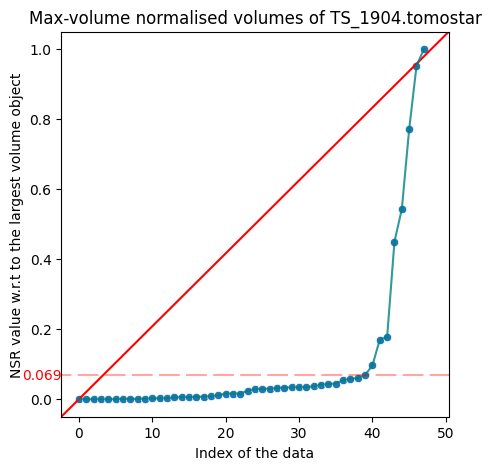

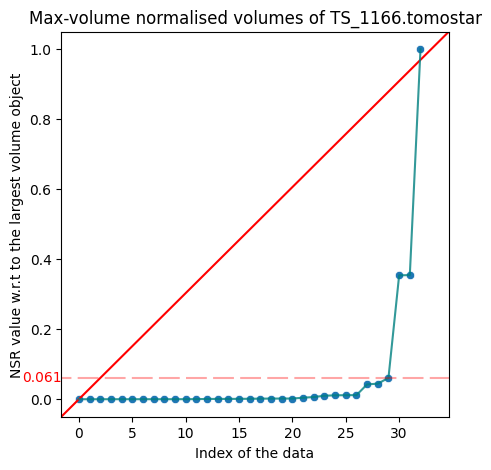

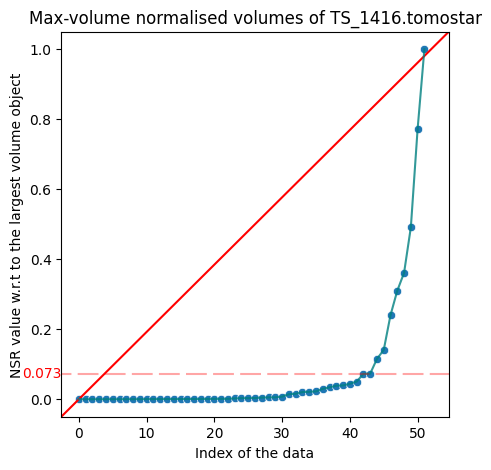

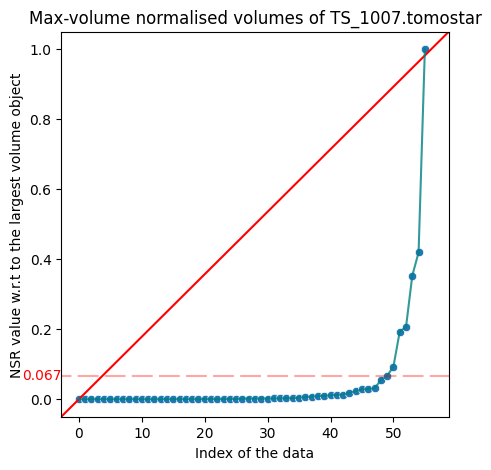

In [ ]:

full_data = extract_and_store(file_choice(files))


### preliminary code for extracting objects from tomogram and storing the objects and associated tomograms into a dictionary

These are the dimensions of the tomogram (ZYX): (412, 624, 624)
Objects retrieved:
dict_keys(['Object22', 'Object41', 'Object40', 'Object5', 'Object6', 'Object33', 'Object3', 'Object29', 'Object27'])
These are the dimensions of the tomogram (ZYX): (412, 624, 624)
Objects retrieved:
dict_keys(['Object26', 'Object1', 'Object19', 'Object4'])
These are the dimensions of the tomogram (ZYX): (412, 624, 624)
Objects retrieved:
dict_keys(['Object16', 'Object46', 'Object26', 'Object9', 'Object24', 'Object43', 'Object22', 'Object37', 'Object1'])
These are the dimensions of the tomogram (ZYX): (412, 624, 624)
Objects retrieved:
dict_keys(['Object5', 'Object16', 'Object37', 'Object38', 'Object12', 'Object36', 'Object20'])


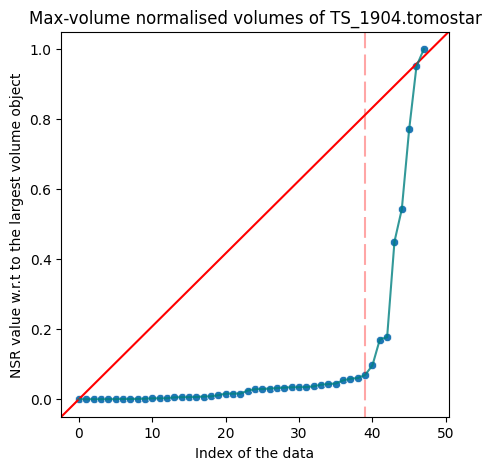

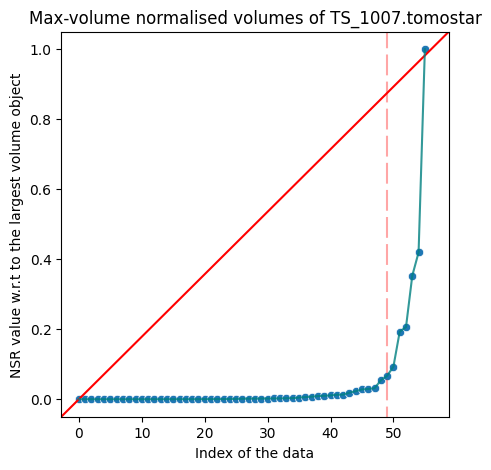

In [ ]:
#get all objects and make a dictionary with all the data in them
full_data_dict = {}

ask_user = input('Before processing, are there any objects of interest you would like to select from the filtered set during processing?')
while ask_user.lower() not in ['y', 'yes', 'n', 'no']:
    print('Answer must be yes or no!')
    ask_user = input('Before processing, are there any objects of interest you would like to select from the filtered set during processing?')
if ask_user.lower() in ['y', 'yes']:
    ask_user == True
elif ask_user.lower() in ['n', 'no']:
    ask_user == False
for index, file in enumerate(files):
    try:
        #BEGIN PROCESSING NOW
        mgraph = get_micrograph_name(file)
        mrc=mrcfile.open(file)
        segmentation = mrc.data.copy()
        shape_zyx = segmentation.shape
        print(f'{'='*50}')
        print(f'Collecting all objects from {mgraph} now....')
        print(f'These are the dimensions of the tomogram (ZYX): {shape_zyx}')

        #insert object retriever function
        objects_dict, volumes = object_extraction(segmentation)
        #volume threshold here
        objects_filtered = knee_detection(objects_dictionary=objects_dict, volume_array=volumes)
        print(f'Objects retrieved:\n{objects_filtered.keys()}')
         #can have user input with objects of interest at the time of processing if they wish
         #alternatively, this can be done retrospectively in a seperate bit of code where users can supply objects of interest they may have, and the final dict can be filtered this way
        object_final = user_decision()
        #append full data dict with key being tomogram name and the value being the objects_filtered dict
        full_data_dict[f'{mgraph}'] = object_final
    
    except Exception as e:
        print(f'\nThere was an error with file:\n{file}')
        print(f'Error:{e}')

In [ ]:
test_dict = full_data_dict['TS_1904.tomostar']
full_data_dict

{'TS_1904.tomostar': {'Object22': <RegionProperties: label=22, bbox=(252, 149, 152, 305, 205, 207)>,
  'Object41': <RegionProperties: label=41, bbox=(334, 118, 488, 396, 199, 601)>,
  'Object40': <RegionProperties: label=40, bbox=(204, 64, 478, 288, 149, 563)>,
  'Object5': <RegionProperties: label=5, bbox=(172, 251, 0, 302, 390, 40)>,
  'Object6': <RegionProperties: label=6, bbox=(185, 384, 0, 342, 531, 151)>,
  'Object33': <RegionProperties: label=33, bbox=(254, 8, 409, 373, 491, 611)>,
  'Object3': <RegionProperties: label=3, bbox=(184, 0, 0, 368, 271, 183)>,
  'Object29': <RegionProperties: label=29, bbox=(204, 257, 200, 340, 624, 413)>,
  'Object27': <RegionProperties: label=27, bbox=(197, 0, 179, 382, 277, 470)>},
 'TS_1166.tomostar': {'Object26': <RegionProperties: label=26, bbox=(251, 401, 490, 314, 588, 624)>,
  'Object1': <RegionProperties: label=1, bbox=(208, 0, 0, 337, 208, 298)>,
  'Object19': <RegionProperties: label=19, bbox=(220, 105, 383, 323, 461, 624)>,
  'Object4': 

In [ ]:
tomo_test = re.findall(r'\d+', input('Tomogram IDs you wish to select from:'))
tomo_test = [f'{x}.tomostar' for x in tomo_test]
tomo_test


['1223.tomostar', '5567.tomostar', '777.tomostar']

In [ ]:
full_data_dict_c = full_data_dict.copy()
full_data_dict_c = user_choice(full_data_dict_c)

full_data_dict_c

{'1904.tomostar': ['33'], '1416.tomostar': ['16', '37']}
1904.tomostar
1416.tomostar


{'TS_1904.tomostar': {'Object33': <RegionProperties: label=33, bbox=(254, 8, 409, 373, 491, 611)>},
 'TS_1166.tomostar': {'Object26': <RegionProperties: label=26, bbox=(251, 401, 490, 314, 588, 624)>,
  'Object1': <RegionProperties: label=1, bbox=(208, 0, 0, 337, 208, 298)>,
  'Object19': <RegionProperties: label=19, bbox=(220, 105, 383, 323, 461, 624)>,
  'Object4': <RegionProperties: label=4, bbox=(214, 249, 0, 399, 624, 415)>},
 'TS_1416.tomostar': {'Object16': <RegionProperties: label=16, bbox=(132, 449, 128, 192, 544, 195)>,
  'Object37': <RegionProperties: label=37, bbox=(98, 43, 329, 272, 410, 624)>},
 'TS_1007.tomostar': {'Object5': <RegionProperties: label=5, bbox=(163, 275, 28, 226, 618, 273)>,
  'Object16': <RegionProperties: label=16, bbox=(247, 461, 178, 325, 536, 258)>,
  'Object37': <RegionProperties: label=37, bbox=(167, 366, 476, 337, 548, 624)>,
  'Object38': <RegionProperties: label=38, bbox=(160, 463, 480, 350, 624, 624)>,
  'Object12': <RegionProperties: label=12, 

## Inspecting outputs

In [ ]:
files

['/Users/jantinoro/Documents/LIDo/Rotation_2/coding/data/segmentation/TS_1904_10.00Apx_MemBrain_seg_v10_beta.ckpt_segmented.mrc',
 '/Users/jantinoro/Documents/LIDo/Rotation_2/coding/data/segmentation/TS_1166_10.00Apx_MemBrain_seg_v10_beta.ckpt_segmented.mrc',
 '/Users/jantinoro/Documents/LIDo/Rotation_2/coding/data/segmentation/TS_1416_10.00Apx_MemBrain_seg_v10_beta.ckpt_segmented.mrc',
 '/Users/jantinoro/Documents/LIDo/Rotation_2/coding/data/segmentation/TS_1007_10.00Apx_MemBrain_seg_v10_beta.ckpt_segmented.mrc']

In [ ]:
mrc = mrcfile.open(files[1]).data.copy()
mrc = mrc.copy()


In [ ]:
object_test = measure.regionprops(mrc)

In [ ]:
object_test[0].coords

array([[208, 197, 114],
       [208, 197, 115],
       [208, 197, 116],
       ...,
       [336, 200, 122],
       [336, 200, 123],
       [336, 200, 124]], shape=(355848, 3))

In [ ]:
full_data

{'TS_1007.tomostar': {'Object16': <RegionProperties: label=16, bbox=(247, 461, 178, 325, 536, 258)>}}

In [ ]:
mrc.shape

(412, 624, 624)

In [ ]:
ts_1166_obj26 = full_data['TS_1007.tomostar']['Object16'].coords
ts_1166_obj26_array = np.zeros(mrc.shape)
ts_1166_obj26_array[ts_1166_obj26[:,0], ts_1166_obj26[:,1], ts_1166_obj26[:,2]] = 1


In [ ]:
cz, cy, cx = center_of_mass(ts_1166_obj26_array)

In [ ]:
verts, faces, norms, values = safe_marching_cubes(map=ts_1166_obj26_array, initial_level=0.5, step_size=0.9)

In [ ]:
verts

array([[246.5, 483. , 222. ],
       [247. , 483. , 221.5],
       [247. , 482.5, 222. ],
       ...,
       [324.5, 501. , 214. ],
       [324.5, 502. , 210. ],
       [324.5, 502. , 211. ]], shape=(49654, 3), dtype=float32)

In [ ]:
norms

array([[-0.9622505 , -0.19245009, -0.19245009],
       [-0.44232586, -0.14744195, -0.8846517 ],
       [-0.61885273, -0.7219949 , -0.30942637],
       ...,
       [ 0.78072006,  0.48795003,  0.39036003],
       [ 0.80812204,  0.5050763 , -0.30304575],
       [ 0.78072006,  0.48795003,  0.39036003]],
      shape=(49654, 3), dtype=float32)

In [ ]:
particle_dict = non_random_membrane_sampling(coords=verts, normal_vectors=norms)

In [ ]:
particle_dict
particle_df = pd.DataFrame.from_dict(particle_dict)

particle_df = particle_df.transpose().reset_index(drop=True)
particle_df_100 = particle_df.iloc[:100, :]
particle_df_100 = particle_df_100.rename(columns={'coordinates':'coordinates (zyx)', 'normal':'normal(zyx)'})


In [ ]:
particle_df_100

,coordinates (zyx),normal(zyx),center of mass(zyx)
0,"[246.5, 483.0, 222.0]","[-0.96, -0.19, -0.19]","[285.41, 498.3, 216.94]"
1,"[247.0, 486.0, 226.5]","[-0.43, -0.26, 0.86]","[285.41, 498.3, 216.94]"
2,"[247.0, 488.0, 221.5]","[-0.45, 0.0, -0.89]","[285.41, 498.3, 216.94]"
3,"[246.5, 491.0, 226.0]","[-1.0, 0.0, 0.0]","[285.41, 498.3, 216.94]"
4,"[246.5, 493.0, 221.0]","[-0.93, 0.0, -0.37]","[285.41, 498.3, 216.94]"
...,...,...,...
95,"[254.0, 495.0, 205.5]","[0.45, 0.0, 0.89]","[285.41, 498.3, 216.94]"
96,"[253.5, 501.0, 229.0]","[0.85, -0.32, -0.42]","[285.41, 498.3, 216.94]"
97,"[253.5, 501.0, 241.0]","[-0.88, 0.44, 0.18]","[285.41, 498.3, 216.94]"
98,"[253.5, 508.0, 214.0]","[0.97, -0.24, 0.0]","[285.41, 498.3, 216.94]"


In [ ]:
np.round(particle_df_100.loc[0, 'normal(zyx)'], 2)

array([-0.96, -0.19, -0.19], dtype=float32)

In [ ]:
#use apply with lambda function

#use loc?

particle_df_100['center of mass(zyx)'] = [np.array([float(cz), float(cy), float(cx)])]* len(particle_df_100)
particle_df_100 = particle_df_100.rename(columns={'coordinates':'coordinates(zyx)', 'normal':'normal(zyx)'})

#rounding numbers to 2 dp

for column in particle_df_100.columns:
    if 'coord' in column: #skip coordinate column
        continue
    particle_df_100[f'{column}'] = particle_df_100[f'{column}'].apply(lambda x: np.round(x, 2))


particle_df_100.to_csv('/Users/jantinoro/Documents/LIDo/Rotation_2/coding/data/ts_1007_object16_particles.csv')

# FINAL workflow

In [ ]:
#when employing the script on the full dataset, these need ot be changed
#us os.getcwd() or sys.argv[] to get directories, or user input perhaps?

data_dir = '/Users/jantinoro/Documents/LIDo/Rotation_2/coding/data/segmentation'
output_dir = '/Users/jantinoro/Documents/LIDo/Rotation_2/coding/data/star_files/'
reconstruction_dir = '/Users/jantinoro/Documents/LIDo/Rotation_2/coding/data/tomo_reconstruction'
#directory/path to the .tomostar files
tomostar_path = "/d/itchy01/u/ucbtj22/warp/tomostar" #this is just for me, needs to be more adaptable 
files = glob.glob(os.path.join(data_dir, "*segmented.*"))
mgraph_suffix = '.tomostar'
star_suffix = '.star'
grid_sampling = 5.0 #in pixels
pixel_size = 10 #angstrom per pixel/voxel


#instantiate the data structure to be used to write the star file
star_dict = {'rlnCoordinateX':[],
             'rlnCoordinateY':[],
             'rlnCoordinateZ':[],
             'rlnOriginX':[],
             'rlnOriginY':[],
             'rlnOriginZ':[],
             'rlnAngleRot':[],
             'rlnAngleTilt':[],
             'rlnAnglePsi':[],
             'rlnLCCmax':[],
             'rlnCutOff':[],
             'rlnSearchStd':[],
             'rlnDetectorPixelSize':[],
             'rlnMicrographName':[]} #This is .tomostar files -> TS_1234.tomostar

total_star_df = pd.DataFrame.from_dict(star_dict)
per_tomogram_star_df = total_star_df.copy()
#will make a particle row dictionary in a for loop within the segmentation mesh - loop over vertices
full_data_dict = {} #dictionary associating tomogram, with objects, and the objects data

In [ ]:
files

['/Users/jantinoro/Documents/LIDo/Rotation_2/coding/data/segmentation/TS_1904_10.00Apx_MemBrain_seg_v10_beta.ckpt_segmented.mrc',
 '/Users/jantinoro/Documents/LIDo/Rotation_2/coding/data/segmentation/TS_1166_10.00Apx_MemBrain_seg_v10_beta.ckpt_segmented.mrc',
 '/Users/jantinoro/Documents/LIDo/Rotation_2/coding/data/segmentation/TS_1416_10.00Apx_MemBrain_seg_v10_beta.ckpt_segmented.mrc',
 '/Users/jantinoro/Documents/LIDo/Rotation_2/coding/data/segmentation/TS_1007_10.00Apx_MemBrain_seg_v10_beta.ckpt_segmented.mrc']

['1007']


These are the dimensions of the tomogram (ZYX): (412, 624, 624)
0.06693800055413258
7 Objects retrieved:
['Object5', 'Object16', 'Object37', 'Object38', 'Object12', 'Object36', 'Object20']
1007.tomostar


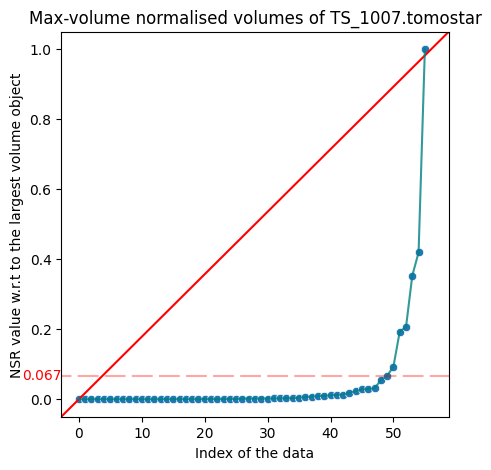

In [ ]:
full_data = extract_and_store(file_choice(files))

In [ ]:
full_data['TS_1007.tomostar']["Object16"].coords

array([[247, 483, 222],
       [247, 483, 223],
       [247, 484, 222],
       ...,
       [324, 501, 214],
       [324, 502, 210],
       [324, 502, 211]], shape=(107310, 3))

In [ ]:
full_data #checking the data

{'TS_1007.tomostar': {'Object16': <RegionProperties: label=16, bbox=(247, 461, 178, 325, 536, 258)>}}

In [ ]:
#loop through the full data dict, objects and perform all of the below
#we need to extract the object using the full box size of the tomogram
#it takes alot of memory, so we only make this full size temporary on a per object basis, so we only have one full object at a time
#this may add significant time to computatioon
#extract the tomogram from full box size, and then perform everything
total_star_df = pd.DataFrame.from_dict(star_dict)
#per_tomo_data_df = pd.DataFrame.from_dict({})
#per_tomogram_star_df = total_star_df.copy()

for tomo, object_data in full_data.items():
    per_tomo_data_df = pd.DataFrame.from_dict({})
    seg_file_path = (glob.glob(os.path.join(data_dir, f"{tomo[:-9]}*")))[0] #item is in a list, getting item out of the list
    with mrcfile.open(seg_file_path) as f:
        shape = f.data.copy().shape
    #tomo_shape = mrcfile.open(seg_file_path).data.copy().shape #zyx
    print(f'{'='*50}')
    print(f'Processing {tomo} now....')
    print(f'These are the dimensions of the tomogram (ZYX): {shape}')
    for object in object_data.values():
        try: 
            object_array = np.zeros(shape=tomo_shape)
            object_coords = object.coords
            object_array[object_coords[:, 0], object_coords[:, 1], object_coords[:, 2]]=1
        except Exception as e:
            print(f'Error with object{object}')
            print(f'Error: {e}')
        #now we perform marching cubes and particle extraction
        #create mesh
        verts, faces, normals, values = safe_marching_cubes(map=object_array, initial_level=0.5, step_size=0.9)
        #make a particle dictionary storing particle index, its coords and normals ### dont need this now

        #get centre of mass
        cent_of_mass = center_of_mass(object_array)

        #sample the membrane
        particle_dict = non_random_membrane_sampling(coords=verts, normal_vectors=normals)
        print(f'{tomo[:-9]} object:{object.label} has got {len(list(particle_dict.keys()))} sampling points!\n')

        #calculate euler angles
        #change euler tilt rot to deal with a dictionary
        data_entries = euler_tilt_rot(centre_of_mass=cent_of_mass, particles=particle_dict, label=int(object.label), micrograph=tomo) #need to give the argument of which tomogram it is from
        data_entry_df = pd.DataFrame.from_dict(data_entries)
        per_tomo_data_df = pd.concat([per_tomo_data_df, data_entry_df], ignore_index=True)
    #turn entries into dataframe, on a per tomogram basis first
    per_tomogram_star_df = pd.DataFrame.from_dict(per_tomo_data_df)
    #write out the star file, on a per-tomogram basis
    file_name = f'{tomo[:-9]}{star_suffix}'
    starfile.write(per_tomogram_star_df, os.path.join(output_dir, file_name))
    #make a star file with all data - optional
    total_star_df = pd.concat([total_star_df, per_tomogram_star_df], ignore_index=True)
#write out a star file with all particles from every tomogram and their respective object
starfile.write(total_star_df, os.path.join(data_dir, 'particles.star'))



        



Processing TS_1007.tomostar now....
These are the dimensions of the tomogram (ZYX): (412, 624, 624)
TS_1007 object:16 has got 1183 sampling points!



## Getting a chimera-readable star file

In [ ]:
ts_1166_path = '/Users/jantinoro/Documents/LIDo/Rotation_2/coding/data/star_files/TS_1166.star' #this is the star file outputted from the code block above
star_path = '/Users/jantinoro/Documents/LIDo/Rotation_2/coding/data/star_files/'

In [ ]:
def chimera_star(star_dir, star_file):
    '''
    Function takes in a star file, and modifies the data in which allows chimerax to read. 
    The output chimera-readable file is written to the desired directory which the final output file is written to.

    :param star_dir: The directory in which the chimer-readable file will be written to
    :param star_file: path of the star file which is to be edited 
    '''
    tomo_name = star_file.split('/')[-1].split('.')[0]
    print(tomo_name)
    df = starfile.read(star_file)

    chimera_readable = df.drop(labels=['rlnMicrographName'], axis=1)
    starfile.write(chimera_readable, f'{star_dir}/{tomo_name}_chimera.star')
    

In [ ]:
'rlnOriginX', 'rlnOriginY', 'rlnOriginZ'

In [ ]:
ts_1166_df = starfile.read(ts_1166_path)

In [ ]:
ts_1166_df

,rlnCoordinateX,rlnCoordinateY,rlnCoordinateZ,rlnOriginX,rlnOriginY,rlnOriginZ,rlnAngleRot,rlnAngleTilt,rlnAnglePsi,rlnMicrographName,rlnObject
0,603.0,521.0,250.5,572.681371,499.686916,281.954207,231.113443,153.434947,90.000000,/d/itchy01/u/ucbtj22/warp/tomostar/TS_1166.tom...,26
1,621.0,491.0,251.5,572.681371,499.686916,281.954207,300.770481,174.289411,0.000000,/d/itchy01/u/ucbtj22/warp/tomostar/TS_1166.tom...,26
2,616.5,494.0,252.0,572.681371,499.686916,281.954207,268.733003,114.094843,-153.434949,/d/itchy01/u/ucbtj22/warp/tomostar/TS_1166.tom...,26
3,621.5,496.0,252.0,572.681371,499.686916,281.954207,50.933319,95.600409,11.309933,/d/itchy01/u/ucbtj22/warp/tomostar/TS_1166.tom...,26
4,614.0,499.0,251.5,572.681371,499.686916,281.954207,69.011335,158.198591,180.000000,/d/itchy01/u/ucbtj22/warp/tomostar/TS_1166.tom...,26
...,...,...,...,...,...,...,...,...,...,...,...
16127,6.5,443.0,392.0,206.791585,423.465070,285.476367,54.291610,63.747625,-9.462322,/d/itchy01/u/ucbtj22/warp/tomostar/TS_1166.tom...,4
16128,3.0,457.5,392.0,206.791585,423.465070,285.476367,285.648981,49.684459,45.000000,/d/itchy01/u/ucbtj22/warp/tomostar/TS_1166.tom...,4
16129,5.0,447.5,394.0,206.791585,423.465070,285.476367,213.768907,50.478804,-45.000000,/d/itchy01/u/ucbtj22/warp/tomostar/TS_1166.tom...,4
16130,0.0,445.5,395.0,206.791585,423.465070,285.476367,294.820858,90.000000,-90.000000,/d/itchy01/u/ucbtj22/warp/tomostar/TS_1166.tom...,4


In [ ]:
chimera_star(star_dir=star_path, star_file= ts_1166_path)

TS_1166


# Testing output by creating an output for WARP and RELION
- Will be testing tomogram 1007, object 16

In [11]:
#when employing the script on the full dataset, these need ot be changed
#us os.getcwd() or sys.argv[] to get directories, or user input perhaps?
# --- Setting up the directories and file paths ---
#data directory where the segmentation files are
data_dir = '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/segmentation'
#where the star files should be written to
output_dir = '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/star_files/'
#where the tomogram reconstructions are
reconstruction_dir = '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/tomo_reconstruction'

#add a directory for where the .cmm file will be written to

#directory/path to the .tomostar files
#I do not need this
tomostar_path = "/d/itchy01/u/ucbtj22/warp/tomostar" #this is just for me, needs to be more adaptable 

# --- Retrieving the segmentatino files ---
files = glob.glob(os.path.join(data_dir, "*segmented.*"))

# --- Setting up parameters and data structures ---
mgraph_suffix = '.tomostar'
star_suffix = '.star'


#instantiate the data structure to be used to write the star file
star_dict = {'rlnCoordinateX':[],
             'rlnCoordinateY':[],
             'rlnCoordinateZ':[],
             'rlnOriginX':[],
             'rlnOriginY':[],
             'rlnOriginZ':[],
             'rlnAngleRot':[],
             'rlnAngleTilt':[],
             'rlnAnglePsi':[],
             'rlnLCCmax':[],
             'rlnCutOff':[],
             'rlnSearchStd':[],
             'rlnDetectorPixelSize':[],
             'rlnMicrographName':[]} #This is .tomostar files -> TS_1234.tomostar

total_star_df = pd.DataFrame.from_dict(star_dict)
per_tomogram_star_df = total_star_df.copy()
#will make a particle row dictionary in a for loop within the segmentation mesh - loop over vertices
full_data_dict = {} #dictionary associating tomogram, with objects, and the objects data


# --- User selection of parameters ---
grid_sampling = 5.0 #in pixels

In [14]:
def chimera_star(star_dir, star_file):
    '''
    Function takes in a star file, and modifies the data in which allows chimerax to read. 
    The output chimera-readable file is written to the desired directory which the final output file is written to.

    :param star_dir: The directory in which the chimer-readable file will be written to
    :param star_file: path of the star file which is to be edited 
    '''
    tomo_name = star_file.split('/')[-1].split('.')[0]
    df = starfile.read(star_file)

    chimera_readable = df.drop(labels=['rlnMicrographName', 'rlnNormalX', 'rlnNormalY', 'rlnNormalZ'], axis=1)
    starfile.write(chimera_readable, f'{star_dir}/{tomo_name}_chimera.star')

In [15]:
def euler_star(centre_of_mass, particles, label, micrograph, **details):
    '''
    This function will take the coordinates of the centre of mass of the segmentation and particle x,y,z coordinates to calculate two euler angles.
    In a spherical coordinate system, to euler angles help determine their position, thus only two are needed.

    :param centre_of_mass: tuple coordinates of the centre of mass of the segmentation, zyx format
    :param particles: particle dictionary containing their coordinates and normal vectors
    :param label: object number
    :param **details: any other details which may be useful to add to the star file, such as micrograph name, or other data which may be useful for downstream processing. This is a flexible argument which can be used to add any other data which may be useful for downstream processing, such as micrograph name, or other data which may be useful for downstream processing.
    :type label: int

    :return: a list of dictionaries wth the entry fields
    :rtype: list

    '''
    tomo_dimension = details['tomo_dimensions'] #zyx format

    global tomostar_path
    centz, centy, centx = centre_of_mass[0], centre_of_mass[1], centre_of_mass[2]
    data_rows = []
    particle_count = 0
    for index, particle in particles.items():
        z_coord, y_coord, x_coord = particle['coordinates'][0], particle['coordinates'][1], particle['coordinates'][2]


        ### potentially having to flip coordinates due to origin conventions 
        #may need ot invert the Z coordinate as Z flipping may be occuring in warp - i.e., the z-axis is ready from a different start point (opposite end)
        #flipping z and y, as origin for warp to top left (same as relion) but my coords are picked from bottom left
        #z_coord = tomo_dimension[0] - z_coord
        #y_coord = tomo_dimension[1] - y_coord

        # --- enforcing directionality of the normals --- #
        dz, dy, dx = ((z_coord - centz), (y_coord - centy), (x_coord - centx))
        #getting normals
        n = particle['normal'] #in zyx
        d = np.array([dz,dy,dx])

        #we are going to calculate the dot product of a reference orientation which is the difference in xyz of particle to center of mass and the normals
        #if they point in roughly same direction (outward) then dot product is positive 
        #if negative, we can discard, as they likely sit on the inside? I hope?
        dot_p = np.dot(n, d)
        if dot_p > 0:
            row={}
            r = m.sqrt(dz**2 + dy**2 + dx**2) #distance from origin to point
            hypot = m.sqrt((dx**2)+(dy**2))
            #getting normals
            nz, ny, nx = particle['normal'][0], particle['normal'][1], particle['normal'][2]
            nz = nz #need to check if the z component is flipped in wrp
            ny = ny
            # --- Coordinate offset towards the cnter of mass (opposite direction from normals) --- #
            #below comments are only relevant if the particle of interest sits within the bi-layer
            #as we have sampled from a gaussian smoothed volume, our coordinates are slightly offset from the membrane, so we can move the coordinates inwards by a small amount, along the direction of the anti-normal
            # to hopefully get closer to the membrane. This is a bit of a hack, but it may help with the downstream processing and alignment.
            #membrane is ~60A thick, with a pixel size of 10A, we would only need ot try 1-3 pixels which is a 10A-30A shift
            #need to make it adaptable - depending on the pixel size, we can specify the number of pixels to shift by, or the angstroms to shift by - aim for 10A-30A shift



            #rot and psi must be positive between 0,360
            #rot random
            #random.seed(1552)
            #rot_seed = np.random.default_rng(155551)
            #rot = rot_seed.uniform(0, 360)
            rot = -(random.uniform(0, 360))
            #rot = np.degrees(m.atan2(dy, dx))
            #rot=0
            #rot = np.degrees(m.atan2(ny, nx))

            #theta
            tilt = np.degrees(m.acos(nz)) #tilt
            #tilt = np.degrees(m.atan2(m.sqrt(nx**2 + ny**2), nz))
            #tilt = np.degrees(m.acos(dz/r))
            #tilt = np.degrees(m.atan2(hypot, dz))
            #this is a test line

            #psi
            #psi=0
            psi = -(np.degrees(m.atan2(ny, nx)))
            #psi = (np.degrees(m.atan2(dy,dx)))
            #psi_seed = np.random.default_rng(255552)
            #psi= psi_seed.uniform(0,360)
            #psi=random.uniform(0, 360)



            row = {'rlnCoordinateX':x_coord,
                'rlnCoordinateY':y_coord,
                'rlnCoordinateZ':z_coord,
                'rlnOriginX':0,
                'rlnOriginY':0,
                'rlnOriginZ':0,
                'rlnAngleRot':rot,
                'rlnAngleTilt':tilt,
                'rlnAnglePsi':psi,
                'rlnMicrographName':micrograph,
                'rlnObject':label,
                'rlnNormalX':nx,
                'rlnNormalY':ny,
                'rlnNormalZ':nz}
            #add object name 
            data_rows.append(row)
    return data_rows
        #use concat to add this entry to the dataframe
                      


Running Extraction: 100%|██████████| 4/4 [00:01<00:00,  2.43file/s, Processing TS_1007.tomostar... | shape (zyx)=(412, 624, 624)]


For tomogram TS_1904.tomostar, 9 objects were selected: ['Object22', 'Object41', 'Object40', 'Object5', 'Object6', 'Object33', 'Object3', 'Object29', 'Object27']

For tomogram TS_1166.tomostar, 4 objects were selected: ['Object26', 'Object1', 'Object19', 'Object4']

For tomogram TS_1416.tomostar, 9 objects were selected: ['Object16', 'Object46', 'Object26', 'Object9', 'Object24', 'Object43', 'Object22', 'Object37', 'Object1']

For tomogram TS_1007.tomostar, 7 objects were selected: ['Object5', 'Object16', 'Object37', 'Object38', 'Object12', 'Object36', 'Object20']


Extraction complete!


Processing 29 objects now...



Processing: 100%|██████████| 29/29 [Elapsed(s):02:20<>Remaining(s):00:00,  4.84s/obj] , Tomogram=TS_1007, Object=20


Particle coordinates and data written to star files in /Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/star_files/!


Tomogram: TS_1416.tomostar, Particles sampled: 19272
Tomogram: TS_1904.tomostar, Particles sampled: 17421
Tomogram: TS_1007.tomostar, Particles sampled: 13652
Tomogram: TS_1166.tomostar, Particles sampled: 8402
Total particles sampled: 58747


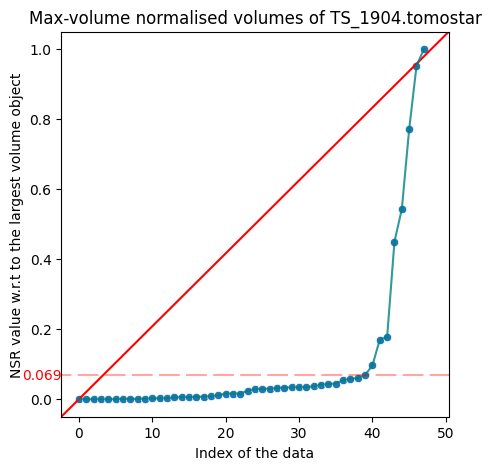

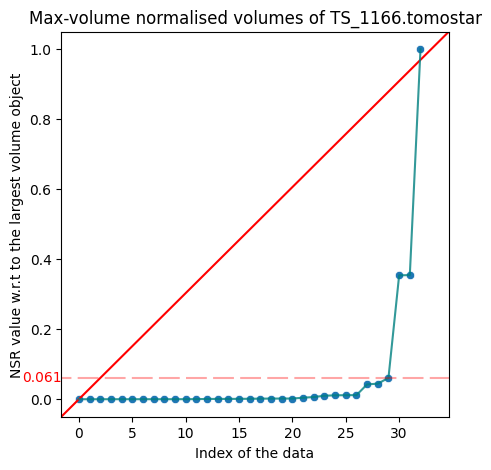

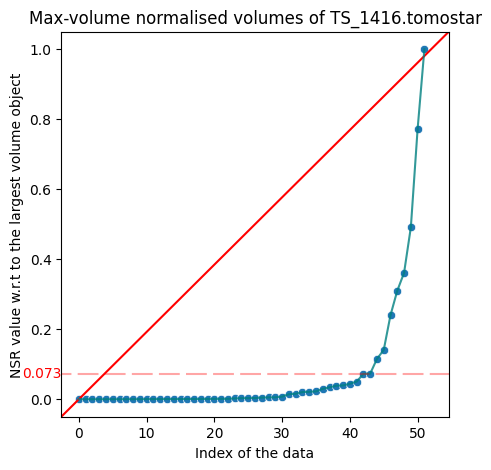

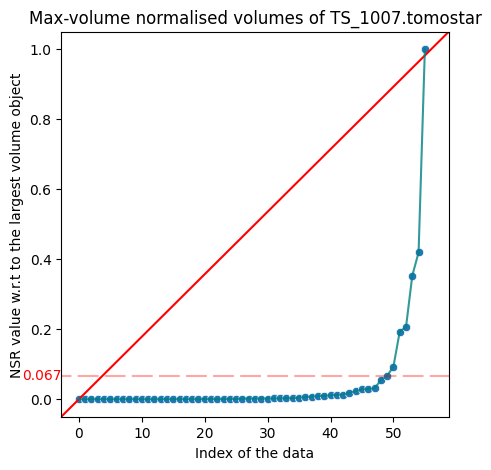

In [ ]:
# --- Extract the files and objects from files
full_data = extract_and_store(file_choice(files))
total_star_df = pd.DataFrame.from_dict(star_dict)
total_particles = 0

pre_ask = input('Do you want to output the particle coordinates and normals into a .cmm file to check in ChimeraX? ')

total_objects = sum(len(obj_data) for obj_data in full_data.values())

print(f'Processing {total_objects} objects now...\n')

# --- Begin processing with a progress bar for the tomograms and their objects --- #
with tqdm(total=total_objects, desc='Processing', unit='obj', dynamic_ncols=True,
          bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [Elapsed(s):{elapsed}<>Remaining(s):{remaining}, {rate_fmt}] {postfix}') as pbar:

    for tomo, object_data in full_data.items():
        per_tomo_data_df = pd.DataFrame.from_dict({})
        # --- Getting the absolute file path of the segmentation file for the current tomogram --- #
        seg_file_path = (glob.glob(os.path.join(data_dir, f"{tomo[:-9]}*")))[0]
        # --- Open up segmentatinofile and extract the shape and pixel size for later use --- #
        with mrcfile.open(seg_file_path) as f:
            shape = f.data.copy().shape
            pixel_size = f.voxel_size.x.copy()
        
        # --- loop through each object in a tomogram --- #
        for object in object_data.values():
            pbar.set_postfix({f"Tomogram": tomo[:-9], "Object": object.label}, refresh=True)

            try:
                # --- Instantiate an array of the same shape as the tomogram --- #
                #This will ensure the particle coordinates are relative to the dimensions of the segmentation
                #the pixel scaling will be handled by WarpTools
                object_array = np.zeros(shape=shape)
                object_coords = object.coords #in zyx
                object_array[object_coords[:, 0], object_coords[:, 1], object_coords[:, 2]] = 1
            except Exception as e:
                pass
            # --- Gaussian smoothing the segmentation to get smoother marching cubes output --- #
            object_array_smooth = gaussian_filter(object_array.astype(float), sigma=3.0)
            # -- now we perform marching cubes and particle extraction --- #
            #this creates a triangualar mesh - these are 'particles'
            #verts, faces, normals, values = safe_marching_cubes(map=object_array_smooth, initial_level=0.5, step_size=0.9)
            verts, faces, normals, values = marching_cubes(volume = object_array_smooth)
            #cent_of_mass = center_of_mass(object_array)
            # --- Enforce grid sampling here --- #
            particle_dict = non_random_membrane_sampling(coords=verts, normal_vectors=normals)

            # --- Calculate euler angles and other data for the star file --- #
            data_entries = euler_star(centre_of_mass=object.centroid, particles=particle_dict, label=int(object.label), micrograph=tomo, tomo_dimensions=shape)

            total_particles += len(data_entries)
            per_tomo_data_df = pd.concat([per_tomo_data_df, pd.DataFrame.from_dict(data_entries)], ignore_index=True)
            # --- Update progress bar --- #
            #As we finish the loop wihtin an object, we update the progress bar
            pbar.update(1)
        # --- Write out a dataframe
        tomogram_star_df = pd.DataFrame.from_dict(per_tomo_data_df)

        if pre_ask.lower() in ['y', 'yes']:
            ask = input(f'Output .cmm for {tomo}? ')
            if ask.lower() in ['y', 'yes']:
                with open(f'/Users/jantinoro/Documents/LIDo/Rotation_2/coding/data/cmm/{tomo[:-9]}_particles.cmm', 'w') as f:
                    f.write('<marker_set name="finer grid, gaussian smoothed">\n')
                    for i in range(per_tomo_data_df.shape[0]):
                        entry = per_tomo_data_df.iloc[i]
                        x, y, z = entry['rlnCoordinateX'], entry['rlnCoordinateY'], entry['rlnCoordinateZ']
                        nx, ny, nz = entry['rlnNormalX'], entry['rlnNormalY'], entry['rlnNormalZ']
                        f.write(f'<marker id="{i}" x="{x*pixel_size}" y="{y*pixel_size}" z="{z*pixel_size}" radius="1"/>\n')
                        f.write(f'<marker id="100{i}" x="{(x*pixel_size)+(pixel_size*nx)}" y="{(y*pixel_size)+(pixel_size*ny)}" z="{(z*pixel_size)+(pixel_size*nz)}" r="3" g="238" b="255" radius="1"/>\n')
                        f.write(f'<link id1="{i}" id2="100{i}" r="3" g="238" b="255" radius="0.5"/>\n')
                    f.write('</marker_set>\n')
        # Write out a star file for the tomogram, with the euler angles and other data for each particle
        starfile.write(tomogram_star_df, os.path.join(f'{output_dir}/euler_troubleshoot/', f"{tomo[:-9]}_smoothed.star"))
        total_star_df = pd.concat([total_star_df, tomogram_star_df], ignore_index=True)
# This writes all particles across all objects across all tomograms into a single star file
starfile.write(total_star_df, os.path.join(output_dir, 'particles.star'))
print(f'Particle coordinates and data written to star files in {output_dir}!')
1
# --- Print out the total number of particles sampled across all tomograms and objects --- #
#loop through the total star df and count the number of rows, which is the number of particles
particle_overview = dict(total_star_df['rlnMicrographName'].value_counts())
print('\n')
for tomogram, particle_count in particle_overview.items():
    print(f'Tomogram: {tomogram}, Particles sampled: {particle_count}')
print(f'Total particles sampled: {total_particles}')

# --- Write it into a star file chimera would read via Artiax --- 
chimera_star('/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/star_files/chimera_star',
             "/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/star_files/euler_troubleshoot/TS_1007_smoothed.star")

In [17]:
def test(**kwargs):
    print(kwargs['test'])

In [18]:
test(test='hello')

hello


In [ ]:
dict(total_star_df['rlnMicrographName'].value_counts())

{'TS_1416.tomostar': np.int64(19272),
 'TS_1904.tomostar': np.int64(17421),
 'TS_1007.tomostar': np.int64(13652),
 'TS_1166.tomostar': np.int64(8402)}

In [16]:
def plot_angles(star_data):
    '''
    Plots the distribution of the euler angles across all of the tomograms processed, to check if there are any biases in the distribution of angles which may affect downstream processing and alignment.
    Rot should have a uniform distribution, while tilt and psi may have some bias depending on the shape of the membrane and the sampling, but we want to check if there are any extreme biases which may affect downstream processing.
    :param star_data: the star dataframe containing the euler angles and other data for each particle
    :return: a plot of the distribution of the euler angles
    '''
    fig, ax = subplots(ncols=3, figsize=(15,6))
    sns.set_style('whitegrid')
    sns.set_context("notebook")
    sns.color_palette('rocket')
    colors= sns.color_palette('viridis')
    sns.histplot(ax = ax[0], data=star_data['rlnAngleTilt'], alpha=0.5, color=colors[0], kde=True, bins=100)
    #sns.kdeplot(ax=ax[0], data=per_tomo_data_df['rlnAngleTilt'], color='black')
    sns.histplot(ax = ax[1], data=star_data['rlnAngleRot'], alpha=0.5, color=colors[1], kde=True, bins=100)
    sns.histplot(ax = ax[2], data=star_data['rlnAnglePsi'], alpha=0.5, color=colors[2], kde=True, bins=100)
    ax[0].set_xlabel('Theta (degrees)');
    ax[1].set_xlabel('Rot (degrees)');
    ax[2].set_xlabel('Azimuthal (degrees)');
    ax[0].set_title('Distribution of Theta Angles');
    ax[1].set_title('Distribution of Rot Angles');
    ax[2].set_title('Distribution of Azimuthal Angles');

    return fig, ax


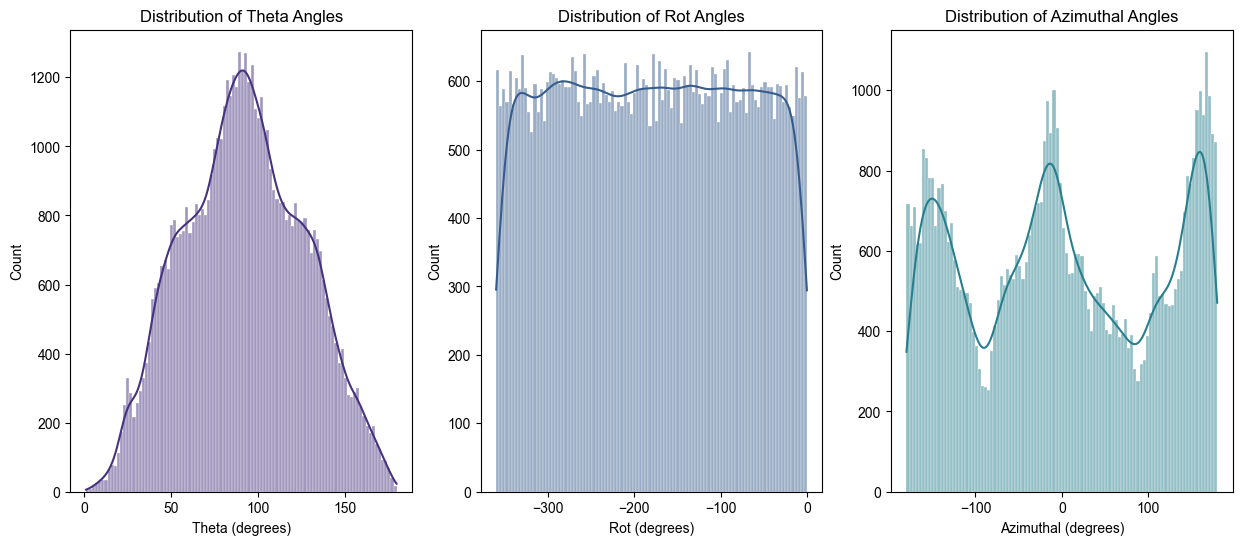

In [ ]:
plot_angles(total_star_df);

## Testing progress bars

### Using progress package
https://pypi.org/project/progress/

In [ ]:
# --- This only works/is visible in the command line
from progress.bar import Bar
import time
bar = Bar('Processing...', max=100, suffix='%(percent).1f%% - %(elapsed_td)s')
for i in range(100):
    # Do some work
    time.sleep(0.05)

    bar.next()
bar.finish()
print('Done!')

### Using ipywidgets and ipython display
https://stackoverflow.com/questions/38861829/how-do-i-implement-a-progress-bar

https://pypi.org/project/ipywidgets/

In [ ]:
# Source - https://stackoverflow.com/a/41457700
# Posted by Stephen McAteer, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-21, License - CC BY-SA 4.0

from ipywidgets import IntProgress
from IPython.display import display
import time

max_count = 100

f = IntProgress(min=0, max=10,
                description = 'Loading...',
                style={'bar_color': 'maroon'},
                orientation='horizontal',
                bar_style='') # 'success', 'info', 'warning', 'danger' or '')
display(f) # display the bar

count = 0
while count <= 10:
    f.value += 1 # signal to increment the progress bar
    time.sleep(.1)
    count += 1


IntProgress(value=0, description='Loading...', max=10, style=ProgressStyle(bar_color='maroon'))

### Using tqdm
https://github.com/tqdm/tqdm#usage

Instantly make your loops show a smart progress meter - just wrap any iterable with tqdm(iterable), and you're done!

In [ ]:

import time

In [ ]:
for i in tqdm(range(100)):
    time.sleep(0.01)

100%|██████████| 100/100 [00:01<00:00, 82.21it/s]


In [ ]:

pbar = tqdm(total=100)
for i in range(10):
    time.sleep(0.1)
    pbar.update(10)
# when not using a with statement, remember to close the progress bar
pbar.close()

100%|██████████| 100/100 [00:01<00:00, 96.00it/s]


In [ ]:
text = ""
for char in tqdm(["a", "b", "c", "d"]):
    time.sleep(0.25)
    text = text + char

100%|██████████| 4/4 [00:01<00:00,  3.92it/s]


In [ ]:
#trange is an optimised version of using range with tqdm, as it automatically closes the progress bar and is more efficient
for i in trange(100):
    time.sleep(0.01)

100%|██████████| 100/100 [00:01<00:00, 81.58it/s]


#### bar_format
bar_format : str, optional
Specify a custom bar string formatting. May impact performance. [default: '{l_bar}{bar}{r_bar}'], where l_bar='{desc}: {percentage:3.0f}%|' and r_bar='| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, ' '{rate_fmt}{postfix}]' 

Possible vars: l_bar, bar, r_bar, n, n_fmt, total, total_fmt, percentage, elapsed, elapsed_s, ncols, nrows, desc, unit, rate, rate_fmt, rate_noinv, rate_noinv_fmt, rate_inv, rate_inv_fmt, postfix, unit_divisor, remaining, remaining_s, eta. Note that a trailing ": " is automatically removed after {desc} if the latter is empty.




In [ ]:
# --- MANUAL --- #
#uses a with statement
#bar format allows us ot highly customise the look of the progress bar
#l_bar is the bar prefix, before the loading bar
#r_bar is the bar suffix, after the loading bar, the data/stats we want to show after the loading bar
#bar format is made up of l_bar, bar, r_bar, and the default is '{l_bar}{bar}{r_bar}'

# -- Default bar format --- #
with tqdm(total=100, bar_format='{l_bar}{bar}{r_bar}') as pbar:
    for i in range(10):
        time.sleep(0.1)
        pbar.update(10)


#customising the bar format
hello = "Hello world!"
with tqdm(total=100, bar_format=('Processing...  {bar}| {l_bar}  {elapsed}<{remaining}, {rate_fmt}, {postfix}'),
        postfix=["Batch", {"value": 0}], position=0,
        colour='#dfff00', unit_scale=True, ncols=130, ascii=' =') as pbar:
    for i in range(10):
        time.sleep(0.1)
        pbar.update(10)



100%|██████████| 100/100 [00:01<00:00, 94.99it/s]
Processing...  ============================================================| 100%|  00:01<00:00, 94.7it/s, ['Batch', {'value': 0}]


In [ ]:
# desc is a varibale which is added to l_bar, so it is shown before the loading bar, and is a good place to show the current batch or object being processed
#post fix is a variable which can be accessed like any other python data structure
hello = "Hello world!"
with tqdm(total=100, bar_format=('{l_bar}{bar}  {elapsed}<{remaining}, {rate_fmt}, {postfix[1][value]}'),
        postfix=["Batch", {"value": 0}], position=0,
        colour='#dfff00', unit_scale=False, ncols=130, desc=f'This is a test: {hello}') as pbar:
    for i in range(10):
        time.sleep(0.1)
        pbar.postfix[1]["value"] = i / 2 # update the value in the postfix
        pbar.update(10)

This is a test: Hello world!: 100%|██████████████████████████████████████████████████████████████████  00:01<00:00, 94.40it/s, 4.5


In [ ]:
## -- Nested progress bars --- #
#many ways to nest, can do it pythonically
for i in tnrange(3, desc='1st loop'):
    time.sleep(0.01)
    for j in tqdm(range(10), desc='2nd loop'):
        time.sleep(0.1)


/var/folders/kq/jpsxymtj09x3l_qtnw438z4w0000gn/T/ipykernel_70097/1311148102.py:2: TqdmDeprecationWarning: Please use `tqdm.notebook.trange` instead of `tqdm.tnrange`
  for i in tnrange(3, desc='1st loop'):


1st loop:   0%|          | 0/3 [00:00<?, ?it/s]

2nd loop: 100%|██████████| 10/10 [00:01<00:00,  9.42it/s]


# Testing if I can make an mrc file with filtered objects
- open a new mrc file, make array of tomogram shape
- put objects back in with their label as pixel value 
- have voxel/pixel value of 10
- re-open mrc, pull out objects again
- re-make the full_data directory

In [22]:
objects_1904 = full_data['TS_1904.tomostar']

NameError: name 'full_data' is not defined

In [ ]:
for file in files:
    if '1904' in file:
        #get the shape
        with mrcfile.open(file, mode='r') as a:
            shape = a.data.copy().shape

        #instantiate an array with same shape 
        filtered_array = np.zeros(shape=shape)
        filtered_array = filtered_array.astype(np.int8)
        #now go through all the objects, get their coordinates and labels and put them back in
        for object in objects_1904.values():
            object_coords = object.coords
            pix_label = np.int8(object.label)
            filtered_array[object_coords[:, 0], object_coords[:, 1], object_coords[:, 2]] = pix_label
        #now make a new mrc file
        with mrcfile.new(name = '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/1904_filt.mrc', overwrite=True) as mrc:
            mrc.set_data(filtered_array)
            mrc.voxel_size = 10

            

In [ ]:
#testing the mrcfile we have created
with mrcfile.open('/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/1904_filt.mrc') as test:
    shape = test.data.copy().shape
    seg_data = test.data.copy()
    print(test.is_volume())
    print(test.voxel_size.x)
    print(seg_data.dtype)

    

True
10.0
int8


In [ ]:
files

['/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/segmentation/TS_1904_10.00Apx_MemBrain_seg_v10_beta.ckpt_segmented.mrc',
 '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/segmentation/TS_1166_10.00Apx_MemBrain_seg_v10_beta.ckpt_segmented.mrc',
 '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/segmentation/TS_1416_10.00Apx_MemBrain_seg_v10_beta.ckpt_segmented.mrc',
 '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/segmentation/TS_1007_10.00Apx_MemBrain_seg_v10_beta.ckpt_segmented.mrc']

In [ ]:
full_data

{'TS_1904.tomostar': {'Object22': <RegionProperties: label=22, bbox=(252, 149, 152, 305, 205, 207)>,
  'Object41': <RegionProperties: label=41, bbox=(334, 118, 488, 396, 199, 601)>,
  'Object40': <RegionProperties: label=40, bbox=(204, 64, 478, 288, 149, 563)>,
  'Object5': <RegionProperties: label=5, bbox=(172, 251, 0, 302, 390, 40)>,
  'Object6': <RegionProperties: label=6, bbox=(185, 384, 0, 342, 531, 151)>,
  'Object33': <RegionProperties: label=33, bbox=(254, 8, 409, 373, 491, 611)>,
  'Object3': <RegionProperties: label=3, bbox=(184, 0, 0, 368, 271, 183)>,
  'Object29': <RegionProperties: label=29, bbox=(204, 257, 200, 340, 624, 413)>,
  'Object27': <RegionProperties: label=27, bbox=(197, 0, 179, 382, 277, 470)>},
 'TS_1166.tomostar': {'Object26': <RegionProperties: label=26, bbox=(251, 401, 490, 314, 588, 624)>,
  'Object1': <RegionProperties: label=1, bbox=(208, 0, 0, 337, 208, 298)>,
  'Object19': <RegionProperties: label=19, bbox=(220, 105, 383, 323, 461, 624)>,
  'Object4': 

## Below are functions from PickMe package - just for testing

In [22]:


def check_make_dir(directory, job_name):
    '''
    When this function is called, it will check if there is an output directory for the current pipeline segment. 
    For example, if this is ran in extract_and_store, it will check if there is an extract directory in output.

    This is done so we can store any results we may want to write into an output directory.

    This function, for now, assumes a certain file structure - as determined by the project structure - we use relative paths to coordinate this.

    :param directory: Path of the directory for which we want to check.
    :param job_name: name of the type of job that is being run
    :type directory: str, pathlike
    '''

    if directory is not None:
        outputs_directories = os.listdir('../outputs/')
        if directory not in outputs_directories:
            os.mkdir(f'../outputs/{directory}')
            output_directory = f'../outputs/{directory}'
            return output_directory
        else:
            output_directory = f'../outputs/{directory}'
            return output_directory
    elif directory is None:
        directory = job_name
        outputs_directories = os.listdir('../outputs/')
        if directory not in outputs_directories:
            os.mkdir(f'../outputs/{directory}')
            output_directory = f'../outputs/{directory}'
            return output_directory
        else: 
            output_directory = f'../outputs/{directory}'
            return output_directory
    

In [23]:
def extract_and_store2(files, output_dir=None):
    '''
    Takes a list of tomogram segmentations, identifies all the objects, filter objects by NSR and provides a filtered object dataset, per tomogram.
    The user also has the option to, from the objects filtered set, choose objects of interest.

    :param input_dir: directory, pathlike, to the directory containing segmentation files
    :param output_dir: directory, pathlike, to  where outputs are to be put
    :type input_dir: string, pathlike
    :type output_dir:string, pathlike

    :return data.csv: CSV file containing the tomograms and their objects
    :rtype: dict

    '''
    full_data = {}

    #Get all objects 
    # --- Begin processing
    with tqdm(total=len(files), desc='Running Extraction', unit='Tomogram', leave=True) as pbar:
        for file in files:
            try:
                mgraph = get_micrograph_name(file)
                with mrcfile.open(file, mode='r') as mrc:
                    segmentation = mrc.data.copy()
                    pix_size = mrc.voxel_size.x
                shape_zyx = segmentation.shape

                #add progress bar update
                pbar.set_postfix_str(f'Processing {mgraph}... | shape (zyx)={shape_zyx}')

                #getting out the objects of the tomograms and filtering out noise
                objects_dict, volumes = object_extraction(segmentation)
                objects_filtered = knee_detection(objects_dictionary=objects_dict, volume_array=volumes, micrograph=mgraph)
                #we now have filtered objects
                #add them to our full data dictionary
                full_data[f'{mgraph}'] = objects_filtered
            except Exception as e:
                print(f'There was an error with file:{file}')
                print(f'Error: {e}')
                raise(e)
            #update bar
            pbar.update(1)
    
    # --- Print out the results of initial extraction
    for tomogram, data in full_data.items():
        print(f'\nFor tomogram {tomogram}, {len(list(data.values()))} objects were selected. Objects: {list(data.keys())}')
    print('\n\nExtraction complete!')
    # --- Making output directories
    output_directory = check_make_dir(directory=output_dir, job_name='extract')

    # --- Writing out the tomogram segmentations to mrc to the output directory
    with tqdm(total= len(full_data.keys()), desc='Writing new objects to mrc.gz', unit='Tomogram', leave=True) as pbar2:
        for tomogram, objects in full_data.items():
            tomo_name = tomogram.split('.')[0]
            filtered_array = np.zeros(shape=shape_zyx)
            filtered_array = filtered_array.astype(np.int8)
            #now go through all the objects, get their coordinates and labels and put them back in
            #add progress bar update
            pbar2.set_postfix_str(f'Processing {tomo_name}...')
            for object in objects.values():
                coords = object.coords
                pix_label = object.label
                filtered_array[coords[:, 0], coords[:, 1], coords[:, 2]] = pix_label
            #now write a new mrc file
            with mrcfile.new(name=f'{os.path.join(output_directory, tomo_name)}.mrc.gz', compression='gzip', overwrite=True) as mrc:
                mrc.set_data(filtered_array)
                mrc.voxel_size = pix_size
            pbar2.update(1)

    return full_data

In [12]:
full_data = extract_and_store2(files=files)

Running Extraction:   0%|          | 0/4 [00:00<?, ?Tomogram/s]

There was an error with file:/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/segmentation/TS_1904_10.00Apx_MemBrain_seg_v10_beta.ckpt_segmented.mrc
Error: name 'get_micrograph_name' is not defined


NameError: name 'get_micrograph_name' is not defined

# Testing napari

- want to see how napari interacts with a python script

## Also using this as a space to double check data structures to make sure I am accessing values correctly

In [5]:
tomogram_list = glob.glob('/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/tomo_reconstruction/*10.00*')
filtered_seg_list = glob.glob('/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/PickMe/outputs/extract/*mrc.gz')

In [18]:
tomogram_list, filtered_seg_list

(['/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/tomo_reconstruction/TS_1007_10.00Apx.mrc',
  '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/tomo_reconstruction/TS_1416_10.00Apx.mrc',
  '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/tomo_reconstruction/TS_1166_10.00Apx.mrc',
  '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/tomo_reconstruction/TS_1904_10.00Apx.mrc'],
 ['/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/PickMe/outputs/extract/TS_1166.mrc.gz',
  '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/PickMe/outputs/extract/TS_1904.mrc.gz',
  '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/PickMe/outputs/extract/TS_1007.mrc.gz',
  '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/PickMe/outputs/extract/TS_1416.mrc.gz'])

In [6]:
data_dict = {}
for tomogram in tomogram_list:
    tomo_id_parts = tomogram.split('/')[-1].split('_')[:2]
    tomo_id = f'{tomo_id_parts[0]}_{tomo_id_parts[1]}'
    #data_dict[tomo_id] = {tomogram:seg for seg in filtered_seg_list if tomo_id in seg}
    data_dict[tomo_id] = {'tomogram': tomogram}
    data_dict[tomo_id].update({'segmentation': seg for seg in filtered_seg_list if tomo_id in seg})

print(data_dict)

{'TS_1007': {'tomogram': '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/tomo_reconstruction/TS_1007_10.00Apx.mrc', 'segmentation': '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/PickMe/outputs/extract/TS_1007.mrc.gz'}, 'TS_1416': {'tomogram': '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/tomo_reconstruction/TS_1416_10.00Apx.mrc', 'segmentation': '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/PickMe/outputs/extract/TS_1416.mrc.gz'}, 'TS_1166': {'tomogram': '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/tomo_reconstruction/TS_1166_10.00Apx.mrc', 'segmentation': '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/PickMe/outputs/extract/TS_1166.mrc.gz'}, 'TS_1904': {'tomogram': '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/tomo_reconstruction/TS_1904_10.00Apx.mrc', 'segmentation': '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/PickMe/outputs/extract/TS_1904.mrc.gz'}}


In [ ]:
with mrcfile.open('/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/tomo_reconstruction/TS_1007_10.00Apx.mrc', mode='r') as test:
    data = test.data.copy()

In [20]:
import napari

In [35]:
full_data

{'TS_1904.tomostar': {'Object22': <RegionProperties: label=22, bbox=(252, 149, 152, 305, 205, 207)>,
  'Object41': <RegionProperties: label=41, bbox=(334, 118, 488, 396, 199, 601)>,
  'Object40': <RegionProperties: label=40, bbox=(204, 64, 478, 288, 149, 563)>,
  'Object5': <RegionProperties: label=5, bbox=(172, 251, 0, 302, 390, 40)>,
  'Object6': <RegionProperties: label=6, bbox=(185, 384, 0, 342, 531, 151)>,
  'Object33': <RegionProperties: label=33, bbox=(254, 8, 409, 373, 491, 611)>,
  'Object3': <RegionProperties: label=3, bbox=(184, 0, 0, 368, 271, 183)>,
  'Object29': <RegionProperties: label=29, bbox=(204, 257, 200, 340, 624, 413)>,
  'Object27': <RegionProperties: label=27, bbox=(197, 0, 179, 382, 277, 470)>},
 'TS_1166.tomostar': {'Object26': <RegionProperties: label=26, bbox=(251, 401, 490, 314, 588, 624)>,
  'Object1': <RegionProperties: label=1, bbox=(208, 0, 0, 337, 208, 298)>,
  'Object19': <RegionProperties: label=19, bbox=(220, 105, 383, 323, 461, 624)>,
  'Object4': 

In [37]:
viewer = napari.Viewer()
for tomogram_id, data in data_dict.items():
    tomogram_path = data['tomogram']
    segmentation_path = data['segmentation']
    #Open up the tomogram and extract the data from it
    with mrcfile.open(tomogram_path, mode='r') as tomogram:
        tomogram_data = tomogram.data.copy()
    #Open up the segmentation and extract the data from it
    with mrcfile.open(segmentation_path, mode='r') as segmentation:
        segmentation_data = segmentation.data.copy()
    #add image and label layers to napari viewer
    viewer.add_image(tomogram_data, name=tomogram_id)
    viewer.add_labels(segmentation_data, name=f'{tomogram_id}_segmentation')

In [ ]:
viewer.layers.selection.active

<Labels layer 'TS_1904_segmentation' at 0x37be37a10>

: 

In [7]:
data_dict

{'TS_1007': {'tomogram': '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/tomo_reconstruction/TS_1007_10.00Apx.mrc',
  'segmentation': '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/PickMe/outputs/extract/TS_1007.mrc.gz'},
 'TS_1416': {'tomogram': '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/tomo_reconstruction/TS_1416_10.00Apx.mrc',
  'segmentation': '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/PickMe/outputs/extract/TS_1416.mrc.gz'},
 'TS_1166': {'tomogram': '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/tomo_reconstruction/TS_1166_10.00Apx.mrc',
  'segmentation': '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/PickMe/outputs/extract/TS_1166.mrc.gz'},
 'TS_1904': {'tomogram': '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/tomo_reconstruction/TS_1904_10.00Apx.mrc',
  'segmentation': '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/PickMe/outputs/extract/TS_1904.mr

In [32]:
full_data

{'TS_1904.tomostar': {'Object22': <RegionProperties: label=22, bbox=(252, 149, 152, 305, 205, 207)>,
  'Object41': <RegionProperties: label=41, bbox=(334, 118, 488, 396, 199, 601)>,
  'Object40': <RegionProperties: label=40, bbox=(204, 64, 478, 288, 149, 563)>,
  'Object5': <RegionProperties: label=5, bbox=(172, 251, 0, 302, 390, 40)>,
  'Object6': <RegionProperties: label=6, bbox=(185, 384, 0, 342, 531, 151)>,
  'Object33': <RegionProperties: label=33, bbox=(254, 8, 409, 373, 491, 611)>,
  'Object3': <RegionProperties: label=3, bbox=(184, 0, 0, 368, 271, 183)>,
  'Object29': <RegionProperties: label=29, bbox=(204, 257, 200, 340, 624, 413)>,
  'Object27': <RegionProperties: label=27, bbox=(197, 0, 179, 382, 277, 470)>},
 'TS_1166.tomostar': {'Object26': <RegionProperties: label=26, bbox=(251, 401, 490, 314, 588, 624)>,
  'Object1': <RegionProperties: label=1, bbox=(208, 0, 0, 337, 208, 298)>,
  'Object19': <RegionProperties: label=19, bbox=(220, 105, 383, 323, 461, 624)>,
  'Object4': 

In [42]:
selections_test = {'TS_1904': [22, 41], "TS_1166": [26, 1], 'TS_1416': [9], 'TS_1007': []}

In [43]:
selections_test

{'TS_1904': [22, 41], 'TS_1166': [26, 1], 'TS_1416': [9], 'TS_1007': []}

In [44]:
final_data={}
for tomo_id, objects in full_data.items():
    selections = selections_test[tomo_id.strip('.tomostar')]
    object_select=[]
    for object in objects.values():
        if object.label in selections:
            object_select.append(object)
            final_data[tomo_id] = object_select

In [45]:
final_data

{'TS_1904.tomostar': [<RegionProperties: label=22, bbox=(252, 149, 152, 305, 205, 207)>,
  <RegionProperties: label=41, bbox=(334, 118, 488, 396, 199, 601)>],
 'TS_1166.tomostar': [<RegionProperties: label=26, bbox=(251, 401, 490, 314, 588, 624)>,
  <RegionProperties: label=1, bbox=(208, 0, 0, 337, 208, 298)>],
 'TS_1416.tomostar': [<RegionProperties: label=9, bbox=(182, 0, 32, 271, 317, 102)>]}

In [46]:
tomogram_lookup = {}
for tomogram in tomogram_list:
    for key in selections_test:
        if key in tomogram:
            tomogram_lookup[key] = tomogram
            break

In [49]:
tomogram_lookup.get("TS_1007")

'/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/tomo_reconstruction/TS_1007_10.00Apx.mrc'

In [67]:
files[0].split('/')[-1].split('_')

['TS',
 '1904',
 '10.00Apx',
 'MemBrain',
 'seg',
 'v10',
 'beta.ckpt',
 'segmented.mrc']

In [59]:
glob.glob('/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/tomo_reconstruction/*')

['/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/tomo_reconstruction/subtomos',
 '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/tomo_reconstruction/TS_1007_10.00Apx.mrc',
 '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/tomo_reconstruction/naive_average.mrc',
 '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/tomo_reconstruction/TS_1416_10.00Apx.mrc',
 '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/tomo_reconstruction/TS_1166_10.00Apx.mrc',
 '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/tomo_reconstruction/naive_average_zyflip.mrc',
 '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/tomo_reconstruction/TS_1904_10.00Apx.mrc',
 '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/data/tomo_reconstruction/naive_average_yflip.mrc']

In [2]:
from pathlib import Path

In [3]:
output = Path('/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/PickMe/outputs/choose')

In [11]:
for i in output.glob('*.gz'):
    print(type(i))

<class 'pathlib.PosixPath'>
<class 'pathlib.PosixPath'>


In [10]:
outputs_jobs = sorted([job for job in (output).glob("**/job[0-9][0-9][0-9]") if job.is_dir()])

In [14]:
b = False

In [41]:
choose_path = Path('/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/PickMe/outputs/choose')

In [67]:
import glob
import re

In [46]:
choose_jobs = sorted([job for job in (choose_path).glob("**/job[0-9][0-9][0-9]") if job.is_dir()])
files2 = glob.glob(f'{choose_jobs[-1]} / *chosen*')

In [58]:
files2 = list(choose_jobs[-1].glob('*chosen*'))

In [76]:
files2

[PosixPath('/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/PickMe/outputs/choose/job009/1904_filtered_chosen.mrc.gz'),
 PosixPath('/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/PickMe/outputs/choose/job009/1416_filtered_chosen.mrc.gz')]

In [79]:
for f in files2:
    f_string = str(f)
    print(f_string)
    print(type(f_string))

/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/PickMe/outputs/choose/job009/1904_filtered_chosen.mrc.gz
<class 'str'>
/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/PickMe/outputs/choose/job009/1416_filtered_chosen.mrc.gz
<class 'str'>


In [71]:
test_string = '/Users/jantinoro/Documents/LIDo/Rotation_2/python_projects/PickMe/outputs/choose/job009/1416_filtered_chosen.mrc.gz'

(re.findall(r'\d+', test_string.split('/')[-1]))[0]

'1416'

In [81]:
def _format_job_number(job_number):
    return f'{int(job_number):03d}'

In [83]:
_format_job_number(21)

'021'